In [71]:
# ROME Structural Analysis - Comprehensive Comparison
# Load data and select case for analysis

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# === CONFIGURATION ===
# Set JSON_FILE to a specific path or leave as None to auto-select latest .jsxn
JSON_FILE = None
analysis_dir = Path("./analysis_out")

if JSON_FILE is None:
    candidates = sorted(analysis_dir.glob("*.jsxn"), key=lambda p: p.stat().st_mtime)
    if not candidates:
        raise FileNotFoundError(f"No .jsxn files found in {analysis_dir}")
    JSON_FILE = str(candidates[-1])

print(f"Using analysis file: {JSON_FILE}")

# Load data
with open(JSON_FILE) as f:
    data = json.load(f)

# Show available cases
print("=== Available Test Cases ===")
print(f"Model: {data['metadata']['model']}")
print(f"Target Layer: {data['metadata']['target_layer']}")
print(f"Number of tests: {data['metadata']['n_tests']}")
print("\nCases:")
for i, test in enumerate(data['tests']):
    status = "✓" if test.get('error') is None else f"✗ ({test['error'][:30]}...)"
    rome_ok = test.get('rome', {}).get('success', False)
    print(f"  [{i}] Case {test['case_id']}: {test['subject']} | ROME: {'✓' if rome_ok else '✗'} | {status}")

# === SELECT CASE ID HERE ===
SELECTED_CASE_ID = 1  # <-- CHANGE THIS TO ANALYZE DIFFERENT CASES

Using analysis file: analysis_out/rome_structural_gpt2-large_2026-01-31_19-14-31.jsxn
=== Available Test Cases ===
Model: gpt2-large
Target Layer: 12
Number of tests: 10

Cases:
  [0] Case 0: Danielle Darrieux | ROME: ✓ | ✓
  [1] Case 1: Edwin of Northumbria | ROME: ✓ | ✓
  [2] Case 2: Toko Yasuda | ROME: ✓ | ✓
  [3] Case 3: Autonomous University of Madrid | ROME: ✓ | ✓
  [4] Case 4: Lyon | ROME: ✗ | ✓
  [5] Case 5: Thomas Joannes Stieltjes | ROME: ✓ | ✓
  [6] Case 6: Anaal Nathrakh | ROME: ✓ | ✓
  [7] Case 7: Apple A5 | ROME: ✓ | ✓
  [8] Case 8: Wellington | ROME: ✗ | ✓
  [9] Case 9: Shree Pundalik | ROME: ✓ | ✓


In [72]:
# 0. Data Integrity & Output Sanity Checks
import math

expected_meta = {'model', 'target_layer', 'n_tests', 'timestamp', 'git_commit', 'seed', 'device', 'dtype'}
present_meta = set(data.get('metadata', {}).keys())
missing_meta = sorted(expected_meta - present_meta)
print("=== DATA INTEGRITY CHECKS ===")
print(f"Missing metadata keys (optional): {missing_meta if missing_meta else 'None'}")

def _collect_invalid_metrics(layer_features, source_label):
    rows = []
    for layer, metrics in (layer_features or {}).items():
        for metric, val in metrics.items():
            try:
                finite = np.isfinite(val)
            except Exception:
                finite = False
            if not finite:
                rows.append({
                    'source': source_label,
                    'layer': int(layer),
                    'metric': metric,
                    'value': val,
                })
    return rows

invalid_rows = []
baseline_blind = data.get('baseline_blind', {})
invalid_rows += _collect_invalid_metrics(baseline_blind.get('layer_features', {}), 'baseline_blind')

for test in data.get('tests', []):
    blind = test.get('blind_detection', {})
    label = f"case_{test.get('case_id')}_blind"
    invalid_rows += _collect_invalid_metrics(blind.get('layer_features', {}), label)

if invalid_rows:
    df_invalid = pd.DataFrame(invalid_rows)
    print(f"Found non-finite metrics: {len(df_invalid)}")
    display(df_invalid.groupby(['metric']).size().sort_values(ascending=False))
    display(df_invalid.head(10))
else:
    print("No NaN/Inf values detected in blind layer_features.")

=== DATA INTEGRITY CHECKS ===
Missing metadata keys (optional): ['device', 'dtype', 'git_commit', 'seed']
No NaN/Inf values detected in blind layer_features.


In [ ]:
# 0b. Structural Module Alignment (current code settings)
from src.structural.blind_detector import BlindMSDDetector
from src.structural.detector import WeightMSDDetector
from src.structural import groupers as groupers_mod

print("=== STRUCTURAL MODULE SETTINGS ===")
blind_detector = BlindMSDDetector()
print({
    "layer_anomaly_threshold": blind_detector.layer_anomaly_threshold,
    "outlier_threshold": blind_detector.outlier_threshold,
    "rank_recovery_threshold": blind_detector.rank_recovery_threshold,
    "gap_ratio_threshold": blind_detector.gap_ratio_threshold,
})

print("Available groupers:")
print([
    groupers_mod.MagnitudeGrouper.__name__,
    groupers_mod.SpectralGrouper.__name__,
    groupers_mod.SparsityGrouper.__name__,
    groupers_mod.RandomGrouper.__name__,
])


=== STRUCTURAL MODULE SETTINGS ===
{'layer_anomaly_threshold': 2.5, 'outlier_threshold': 0.08, 'rank_recovery_threshold': 15.0, 'gap_ratio_threshold': 5.0}
Available groupers:
['MagnitudeGrouper', 'SpectralGrouper', 'SparsityGrouper', 'RandomGrouper']


In [74]:
case = next((t for t in data['tests'] if t['case_id'] == SELECTED_CASE_ID), None)
if case is None:
    raise ValueError(f"Case {SELECTED_CASE_ID} not found!")

target_layer = data['metadata']['target_layer']
print(f"=== Analyzing Case {SELECTED_CASE_ID}: {case['subject']} ===")
print(f"Target (edited) layer: {target_layer}")

if case.get('error'):
    print(f"⚠️  Case has error: {case['error']}")
else:
    rome = case['rome']
    print(f"\nROME Edit Results:")
    print(f"  Success: {rome['success']}")
    print(f"  Predicted: {rome['predicted']}")
    print(f"  k_norm: {rome['k_norm']:.4f}")
    print(f"  v_norm: {rome['v_norm']:.4f}")
    print(f"  delta_norm: {rome['delta_norm']:.4f}")

=== Analyzing Case 1: Edwin of Northumbria ===
Target (edited) layer: 12

ROME Edit Results:
  Success: True
  Predicted:  Islam
  k_norm: 6.9071
  v_norm: 68.4485
  delta_norm: 67.2609


## 1. Normal Detection - Affected Layer vs Other Layers

This uses the original weights as reference to detect changes.

=== NORMAL DETECTION (with original weights reference) ===

Detected anomalous layer: 12 ✓ CORRECT
Layer Z-score: 5.9161
Is likely ROME: True
P-value: 0.000000
Rank-one score: 1.000000
Effective rank of delta: 1.0001


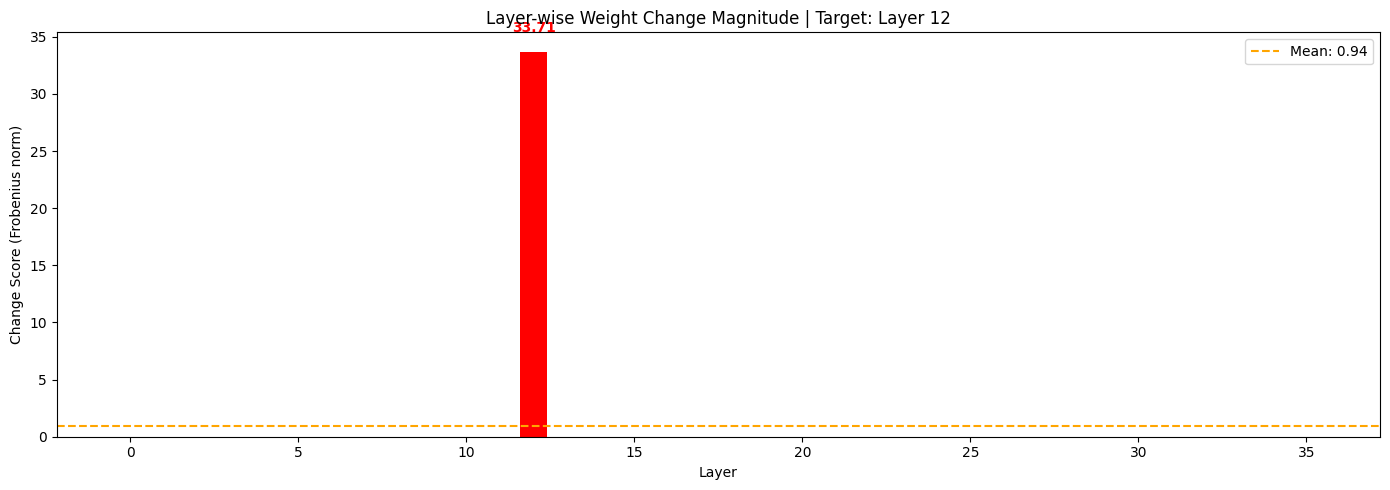


--- Layer Score Statistics ---
Target layer (12) score: 33.7071
Other layers mean: 0.0000
Other layers std: 0.0000
Target vs others ratio: 337070693969.73x


In [75]:
normal = case.get('normal_detection', {})

if normal:
    print("=== NORMAL DETECTION (with original weights reference) ===\n")
    
    # Detection result
    detected_layer = normal.get('anomalous_layer')
    is_correct = detected_layer == target_layer
    print(f"Detected anomalous layer: {detected_layer} {'✓ CORRECT' if is_correct else '✗ WRONG'}")
    print(f"Layer Z-score: {normal.get('layer_z_score', 0):.4f}")
    print(f"Is likely ROME: {normal.get('is_likely_rome', False)}")
    print(f"P-value: {normal.get('p_value', 1):.6f}")
    print(f"Rank-one score: {normal.get('rank_one_score', 0):.6f}")
    print(f"Effective rank of delta: {normal.get('effective_rank', 0):.4f}")
    
    # All layer scores comparison
    all_scores = normal.get('all_layer_scores', {})
    layers = sorted([int(k) for k in all_scores.keys()])
    scores = [all_scores[str(l)] for l in layers]
    
    fig, ax = plt.subplots(figsize=(14, 5))
    colors = ['red' if l == target_layer else 'steelblue' for l in layers]
    bars = ax.bar(layers, scores, color=colors)
    ax.axhline(y=np.mean(scores), color='orange', linestyle='--', label=f'Mean: {np.mean(scores):.2f}')
    ax.set_xlabel('Layer')
    ax.set_ylabel('Change Score (Frobenius norm)')
    ax.set_title(f'Layer-wise Weight Change Magnitude | Target: Layer {target_layer}')
    ax.legend()
    
    # Annotate target layer
    if str(target_layer) in all_scores:
        target_score = all_scores[str(target_layer)]
        ax.annotate(f'{target_score:.2f}', xy=(target_layer, target_score), 
                    xytext=(target_layer, target_score + max(scores)*0.05),
                    ha='center', fontweight='bold', color='red')
    plt.tight_layout()
    plt.show()
    
    # Statistics
    other_scores = [s for l, s in zip(layers, scores) if l != target_layer]
    target_score = all_scores.get(str(target_layer), 0)
    print(f"\n--- Layer Score Statistics ---")
    print(f"Target layer ({target_layer}) score: {target_score:.4f}")
    print(f"Other layers mean: {np.mean(other_scores):.4f}")
    print(f"Other layers std: {np.std(other_scores):.4f}")
    print(f"Target vs others ratio: {target_score / (np.mean(other_scores) + 1e-10):.2f}x")
else:
    print("No normal detection data available")

=== NEURON GROUP ANALYSIS ===

Most affected group: magnitude/magnitude_q4
Group MSD: 0.091062


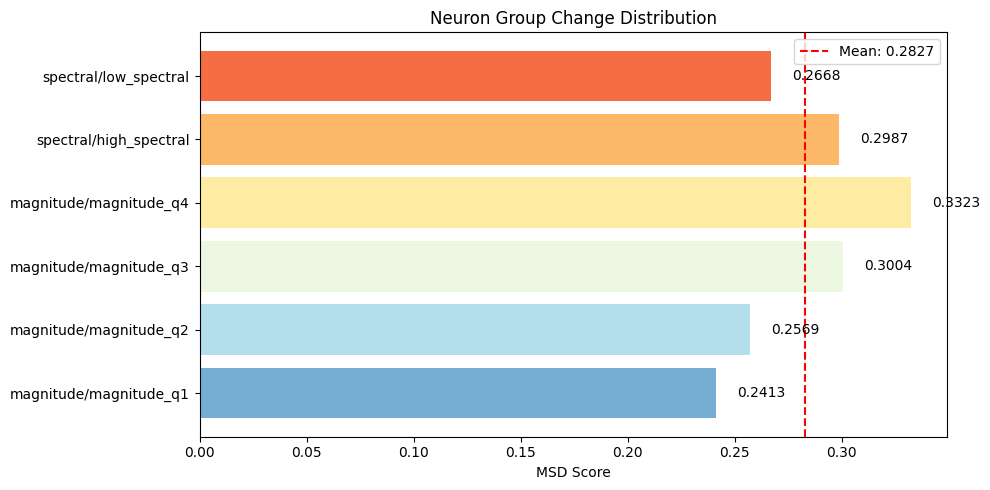


--- Top Singular Values of Delta ---
  σ_1: 33.677258
  σ_2: 0.000005
  σ_3: 0.000003
  σ_4: 0.000003
  σ_5: 0.000002
  Ratio σ₁/σ₂: 7228490.05


In [76]:
# Group-level analysis (which neuron groups changed most)
if normal and 'group_scores' in normal:
    print("=== NEURON GROUP ANALYSIS ===\n")
    print(f"Most affected group: {normal.get('most_affected_group')}")
    print(f"Group MSD: {normal.get('group_msd', 0):.6f}")
    
    group_scores = normal['group_scores']
    groups = list(group_scores.keys())
    values = list(group_scores.values())
    
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, len(groups)))
    bars = ax.barh(groups, values, color=colors)
    ax.set_xlabel('MSD Score')
    ax.set_title('Neuron Group Change Distribution')
    ax.axvline(x=np.mean(values), color='red', linestyle='--', label=f'Mean: {np.mean(values):.4f}')
    ax.legend()
    
    # Add values on bars
    for bar, val in zip(bars, values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')
    
    plt.tight_layout()
    plt.show()
    
    # Top singular values of delta
    if 'top_singular_values' in normal:
        svs = normal['top_singular_values']
        print(f"\n--- Top Singular Values of Delta ---")
        for i, sv in enumerate(svs):
            print(f"  σ_{i+1}: {sv:.6f}")
        print(f"  Ratio σ₁/σ₂: {svs[0]/(svs[1]+1e-10):.2f}")

## 2. Blind Detection - Layer Features Comparison

This analyzes only the modified weights (no original reference). Compares the target layer features vs all other layers.

In [77]:
blind = case.get('blind_detection', {})

if blind and 'layer_features' in blind:
    print("=== BLIND DETECTION (no original reference) ===\n")
    
    detected_layer = blind.get('anomalous_layer')
    is_correct = detected_layer == target_layer
    print(f"Detected anomalous layer: {detected_layer} {'✓ CORRECT' if is_correct else '✗ WRONG'}")
    print(f"Layer anomaly score: {blind.get('layer_anomaly_score', 0):.4f}")
    
    # Build DataFrame from layer features
    layer_features = blind['layer_features']
    df_layers = pd.DataFrame.from_dict(layer_features, orient='index')
    df_layers.index = df_layers.index.astype(int)
    df_layers = df_layers.sort_index()
    
    # Replace infinity with NaN for calculations
    df_layers = df_layers.replace([np.inf, -np.inf], np.nan)
    
    print(f"\n--- Layer Features Overview ---")
    display(df_layers)
else:
    print("No blind detection data available")

=== BLIND DETECTION (no original reference) ===

Detected anomalous layer: 12 ✓ CORRECT
Layer anomaly score: 4.8122

--- Layer Features Overview ---


,effective_rank,spectral_gap,top1_energy,pcs,norm_cv,row_alignment,spectral_entropy
0,1211.822510,1.506440,0.021497,8.099453e-12,0.145358,20.206240,0.965706
1,1195.037354,1.902136,0.040131,2.854337e-11,0.165327,17.151989,0.949255
2,1195.177612,1.623153,0.030207,1.576771e-11,0.143752,19.116989,0.954293
3,1196.685303,1.720914,0.022570,1.306741e-11,0.143546,24.453062,0.958990
4,1193.300659,1.826945,0.019357,1.016803e-11,0.155117,28.701370,0.959284
5,1194.590698,1.491796,0.014681,7.250728e-12,0.148950,28.470295,0.960847
6,1195.452271,1.346048,0.014859,5.795792e-12,0.147715,29.226898,0.960187
7,1191.991577,1.186313,0.016121,6.738569e-12,0.151526,20.566414,0.957049
8,1186.676514,1.818577,0.030058,7.495851e-12,0.152377,17.137869,0.950408
9,1186.989990,2.095147,0.033119,7.998608e-12,0.158635,15.974882,0.949172


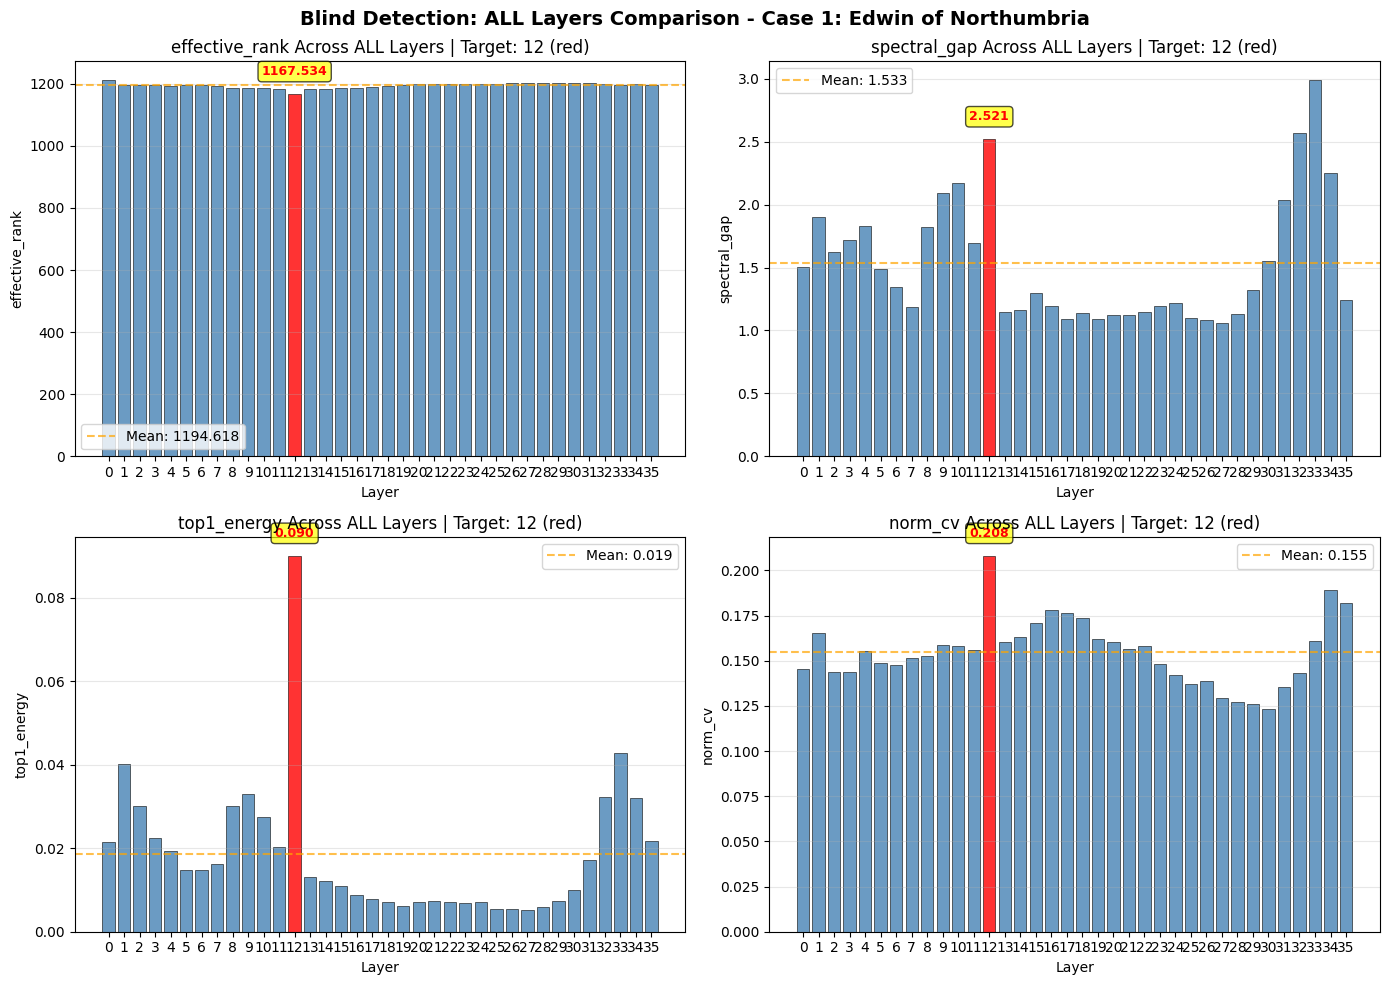

In [78]:
# Visualize each metric: Target Layer vs ALL Other Layers
if blind and 'layer_features' in blind:
    metrics = ['effective_rank', 'spectral_gap', 'top1_energy', 'norm_cv']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for ax, metric in zip(axes, metrics):
        # Get ALL layer values for this metric (no dropna on index)
        all_layers = list(range(len(df_layers)))
        vals = [df_layers.loc[l, metric] if l in df_layers.index else np.nan for l in all_layers]
        
        colors = ['red' if l == target_layer else 'steelblue' for l in all_layers]
        bars = ax.bar(all_layers, vals, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
        
        # Add mean line (excluding NaN)
        valid_vals = [v for v in vals if not np.isnan(v)]
        if valid_vals:
            ax.axhline(y=np.mean(valid_vals), color='orange', linestyle='--', alpha=0.7, label=f'Mean: {np.mean(valid_vals):.3f}')
        
        ax.set_xlabel('Layer')
        ax.set_ylabel(metric)
        ax.set_title(f'{metric} Across ALL Layers | Target: {target_layer} (red)')
        ax.set_xticks(all_layers)
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        
        # Annotate target layer value
        if target_layer < len(vals) and not np.isnan(vals[target_layer]):
            max_val = np.nanmax(vals)
            ax.annotate(f'{vals[target_layer]:.3f}', xy=(target_layer, vals[target_layer]), 
                       xytext=(target_layer, vals[target_layer] + max_val*0.05),
                       ha='center', fontweight='bold', color='red', fontsize=9,
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    plt.suptitle(f'Blind Detection: ALL Layers Comparison - Case {SELECTED_CASE_ID}: {case["subject"]}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [79]:
# Statistical comparison: Target Layer vs Others
if blind and 'layer_features' in blind:
    print("=== TARGET LAYER vs OTHER LAYERS - STATISTICAL COMPARISON ===\n")
    
    metrics = ['effective_rank', 'spectral_gap', 'top1_energy', 'norm_cv']
    
    comparison_data = []
    for metric in metrics:
        target_val = df_layers.loc[target_layer, metric] if target_layer in df_layers.index else np.nan
        other_vals = df_layers.loc[df_layers.index != target_layer, metric].dropna()
        
        if not np.isnan(target_val) and len(other_vals) > 0:
            mean_other = other_vals.mean()
            std_other = other_vals.std()
            z_score = (target_val - mean_other) / (std_other + 1e-10)
            percentile = (other_vals < target_val).sum() / len(other_vals) * 100
            
            comparison_data.append({
                'Metric': metric,
                'Target Layer': f'{target_val:.4f}',
                'Others Mean': f'{mean_other:.4f}',
                'Others Std': f'{std_other:.4f}',
                'Z-Score': f'{z_score:.2f}',
                'Percentile': f'{percentile:.1f}%',
                'Discrepancy': '⚠️ HIGH' if abs(z_score) > 2 else '✓ Normal'
            })
    
    df_comp = pd.DataFrame(comparison_data)
    display(df_comp)

=== TARGET LAYER vs OTHER LAYERS - STATISTICAL COMPARISON ===



,Metric,Target Layer,Others Mean,Others Std,Z-Score,Percentile,Discrepancy
0,effective_rank,1167.5336,1195.3918,7.0567,-3.95,0.0%,⚠️ HIGH
1,spectral_gap,2.5211,1.5044,0.4785,2.12,94.3%,⚠️ HIGH
2,top1_energy,0.0901,0.0165,0.0109,6.73,100.0%,⚠️ HIGH
3,norm_cv,0.2082,0.1534,0.0161,3.41,100.0%,⚠️ HIGH


## 3. Baseline vs Post-Edit Blind Detection Comparison

Compare the blind detection results before and after ROME edit to see what changed.

In [80]:
baseline_blind = data.get('baseline_blind', {})
case_blind = case.get('blind_detection', {})

if baseline_blind and case_blind and 'layer_features' in baseline_blind and 'layer_features' in case_blind:
    print("=== BASELINE vs POST-EDIT COMPARISON ===\n")
    
    baseline_features = baseline_blind['layer_features']
    post_features = case_blind['layer_features']
    
    # Build comparison DataFrames
    df_baseline = pd.DataFrame.from_dict(baseline_features, orient='index')
    df_baseline.index = df_baseline.index.astype(int)
    df_baseline = df_baseline.sort_index().replace([np.inf, -np.inf], np.nan)
    
    df_post = pd.DataFrame.from_dict(post_features, orient='index')
    df_post.index = df_post.index.astype(int)
    df_post = df_post.sort_index().replace([np.inf, -np.inf], np.nan)
    
    # Compute differences
    df_diff = df_post - df_baseline
    
    print(f"Baseline anomalous layer: {baseline_blind.get('anomalous_layer')}")
    print(f"Post-edit anomalous layer: {case_blind.get('anomalous_layer')}")
    print(f"\n--- Feature Differences (Post - Baseline) ---")
    display(df_diff.style.background_gradient(cmap='RdBu_r', axis=None))
    
    # Highlight the target layer
    print(f"\n--- Target Layer {target_layer} Changes ---")
    if target_layer in df_diff.index:
        target_changes = df_diff.loc[target_layer]
        for metric, change in target_changes.items():
            if not np.isnan(change):
                direction = "↑" if change > 0 else "↓" if change < 0 else "="
                print(f"  {metric}: {change:+.6f} {direction}")
else:
    print("Baseline or case blind detection data not available")

=== BASELINE vs POST-EDIT COMPARISON ===

Baseline anomalous layer: 33
Post-edit anomalous layer: 12

--- Feature Differences (Post - Baseline) ---


,effective_rank,spectral_gap,top1_energy,pcs,norm_cv,row_alignment,spectral_entropy
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000



--- Target Layer 12 Changes ---
  effective_rank: -16.623047 ↓
  spectral_gap: +1.233876 ↑
  top1_energy: +0.074512 ↑
  pcs: +0.000000 ↑
  norm_cv: +0.059245 ↑
  row_alignment: +10.396963 ↑
  spectral_entropy: -0.043606 ↓


DEBUG: Showing 36 layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]
effective_rank: 1 non-zero values out of 36 total
spectral_gap: 1 non-zero values out of 36 total
top1_energy: 1 non-zero values out of 36 total
norm_cv: 1 non-zero values out of 36 total


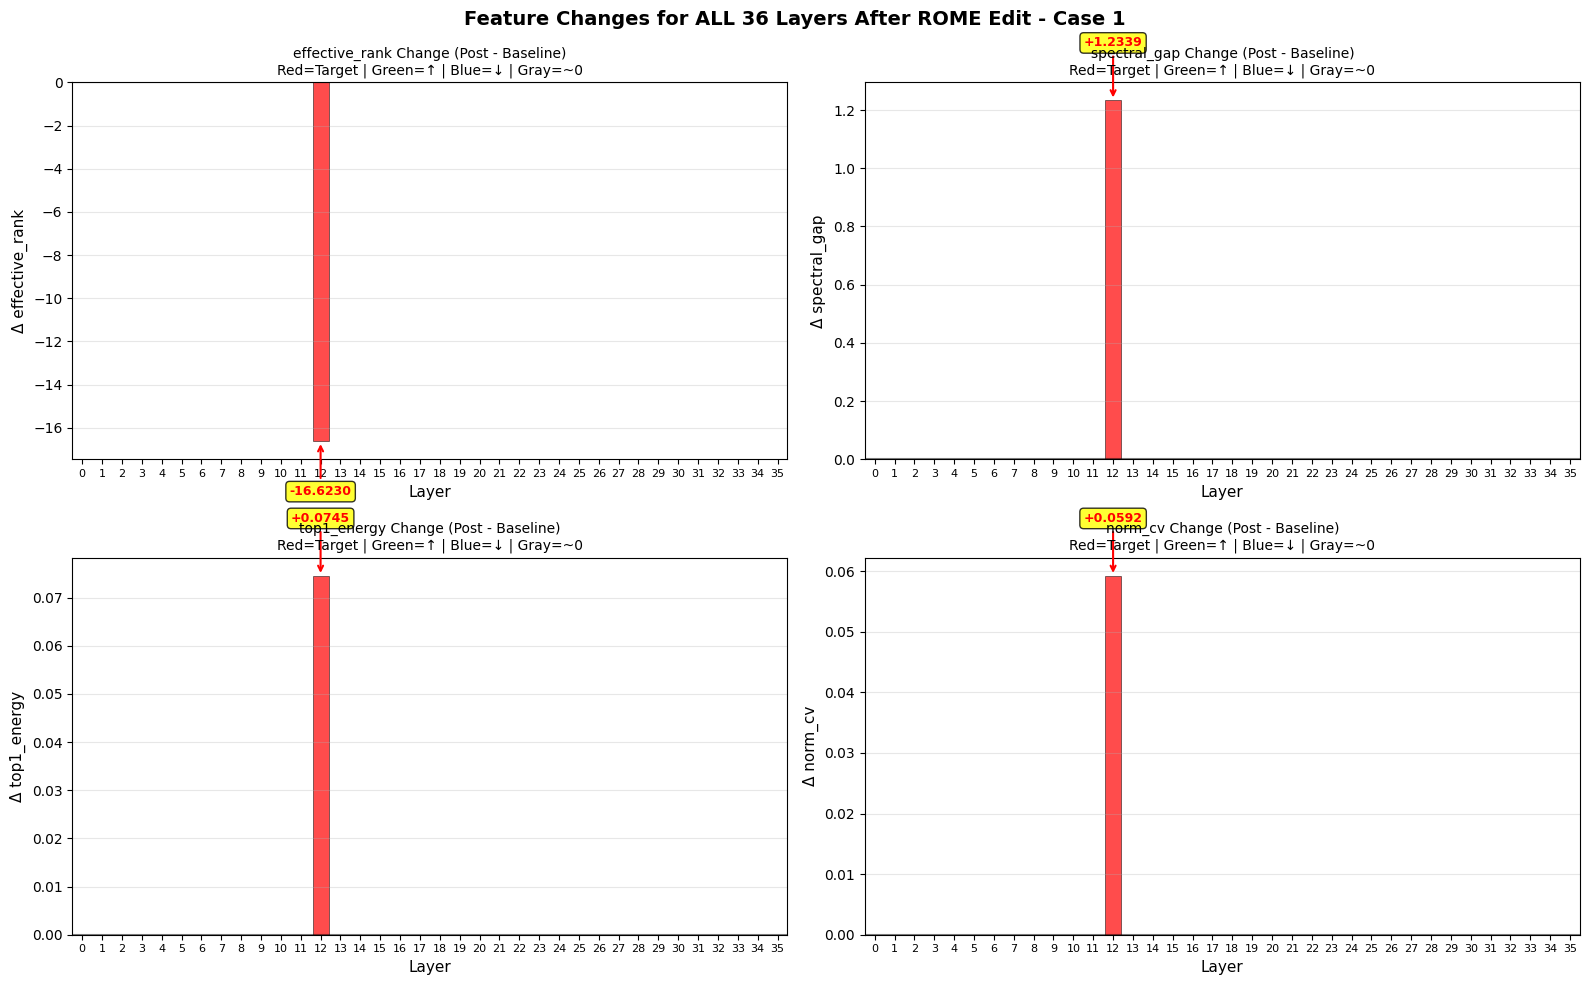


DETAILED CHANGE SUMMARY FOR ALL 36 LAYERS

EFFECTIVE_RANK:
  Target layer 12: -16.623047
  All other layers have zero/negligible change

SPECTRAL_GAP:
  Target layer 12: +1.233876
  All other layers have zero/negligible change

TOP1_ENERGY:
  Target layer 12: +0.074512
  All other layers have zero/negligible change

NORM_CV:
  Target layer 12: +0.059245
  All other layers have zero/negligible change


In [81]:
# Visualize differences: Target Layer vs ALL Other Layers
if 'df_diff' in dir():
    metrics = ['effective_rank', 'spectral_gap', 'top1_energy', 'norm_cv']
    
    # Get the actual layer indices from the dataframe
    all_layers = sorted(df_diff.index.tolist())
    print(f"DEBUG: Showing {len(all_layers)} layers: {all_layers}")
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
    
    for ax, metric in zip(axes, metrics):
        # Get values for ALL layers
        vals = [df_diff.loc[l, metric] if l in df_diff.index else 0 for l in all_layers]
        
        # Debug: show value range
        non_zero_vals = [v for v in vals if abs(v) > 1e-10]
        print(f"{metric}: {len(non_zero_vals)} non-zero values out of {len(vals)} total")
        
        # Color coding: red=target, green=positive change, blue=negative change
        colors = []
        for l, v in zip(all_layers, vals):
            if l == target_layer:
                colors.append('red')
            elif abs(v) < 1e-10:  # essentially zero
                colors.append('lightgray')
            elif v > 0:
                colors.append('green')
            else:
                colors.append('blue')
        
        # Create bars with explicit positioning
        bars = ax.bar(range(len(all_layers)), vals, color=colors, alpha=0.7, 
                      edgecolor='black', linewidth=0.5, width=0.8)
        ax.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1.5)
        
        # Set x-axis to show ALL layer numbers
        ax.set_xlabel('Layer', fontsize=11)
        ax.set_ylabel(f'Δ {metric}', fontsize=11)
        ax.set_title(f'{metric} Change (Post - Baseline)\nRed=Target | Green=↑ | Blue=↓ | Gray=~0', fontsize=10)
        ax.set_xticks(range(len(all_layers)))
        ax.set_xticklabels(all_layers, fontsize=8)
        ax.set_xlim(-0.5, len(all_layers) - 0.5)  # Ensure all bars are visible
        ax.grid(axis='y', alpha=0.3)
        
        # Annotate target layer with arrow
        target_idx = all_layers.index(target_layer)
        target_val = vals[target_idx]
        if abs(target_val) > 1e-10:
            abs_max = max(abs(v) for v in vals)
            offset = abs_max * 0.15 if target_val >= 0 else -abs_max * 0.15
            ax.annotate(f'{target_val:+.4f}', xy=(target_idx, target_val), 
                       xytext=(target_idx, target_val + offset),
                       ha='center', fontweight='bold', color='red', fontsize=9,
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8),
                       arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
    
    plt.suptitle(f'Feature Changes for ALL {len(all_layers)} Layers After ROME Edit - Case {SELECTED_CASE_ID}', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print detailed summary of ALL layers
    print(f"\n{'='*70}")
    print(f"DETAILED CHANGE SUMMARY FOR ALL {len(all_layers)} LAYERS")
    print(f"{'='*70}")
    for metric in metrics:
        vals = [df_diff.loc[l, metric] if l in df_diff.index else 0 for l in all_layers]
        target_idx = all_layers.index(target_layer)
        target_change = vals[target_idx]
        other_changes = [v for i, v in enumerate(vals) if all_layers[i] != target_layer and abs(v) > 1e-10]
        
        print(f"\n{metric.upper()}:")
        print(f"  Target layer {target_layer}: {target_change:+.6f}")
        if other_changes:
            print(f"  Other non-zero layers: {len(other_changes)}/{len(all_layers)-1}")
            print(f"  Other layers mean: {np.mean(other_changes):+.6f}")
            print(f"  Other layers range: [{np.min(other_changes):+.6f}, {np.max(other_changes):+.6f}]")
            print(f"  Positive changes: {sum(1 for v in vals if v > 1e-10)}")
            print(f"  Negative changes: {sum(1 for v in vals if v < -1e-10)}")
            print(f"  Near-zero changes: {sum(1 for v in vals if abs(v) <= 1e-10)}")
        else:
            print(f"  All other layers have zero/negligible change")

## 4. Cross-Case Metric Summary

Aggregate how structural metrics shift across all test cases.

In [82]:
# Summary across all test cases - METRIC SHIFTS FOCUS
print("=== CROSS-CASE METRIC SHIFT SUMMARY ===\n")

summary_rows = []
for test in data['tests']:
    if test.get('error'):
        continue
    
    rome = test.get('rome', {})
    normal = test.get('normal_detection', {})
    blind = test.get('blind_detection', {})
    
    # Get target layer feature changes (if baseline exists)
    baseline_lf = data.get('baseline_blind', {}).get('layer_features', {}).get(str(target_layer), {})
    case_lf = blind.get('layer_features', {}).get(str(target_layer), {})
    
    row = {
        'case_id': test['case_id'],
        'subject': test['subject'][:25],
        'rome_success': rome.get('success', False),
        'delta_norm': rome.get('delta_norm', 0),
        'k_norm': rome.get('k_norm', 0),
        'v_norm': rome.get('v_norm', 0),
        'rank_one_score': normal.get('rank_one_score', 0),
        'effective_rank': normal.get('effective_rank', 0),
        # Target layer feature shifts
        'Δ_eff_rank': case_lf.get('effective_rank', 0) - baseline_lf.get('effective_rank', 0) if baseline_lf else None,
        'Δ_spectral_gap': case_lf.get('spectral_gap', 0) - baseline_lf.get('spectral_gap', 0) if baseline_lf else None,
        'Δ_top1_energy': case_lf.get('top1_energy', 0) - baseline_lf.get('top1_energy', 0) if baseline_lf else None,
    }
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
display(df_summary)

# Metric shift statistics
n_tests = len(df_summary)
print(f"\n--- ROME Edit Magnitude Statistics ---")
print(f"Total valid tests: {n_tests}")
print(f"ROME success rate: {df_summary['rome_success'].sum()}/{n_tests} ({df_summary['rome_success'].mean()*100:.1f}%)")
print(f"Mean delta_norm: {df_summary['delta_norm'].mean():.2f} ± {df_summary['delta_norm'].std():.2f}")
print(f"Mean k_norm: {df_summary['k_norm'].mean():.4f} ± {df_summary['k_norm'].std():.4f}")
print(f"Mean v_norm: {df_summary['v_norm'].mean():.2f} ± {df_summary['v_norm'].std():.2f}")
print(f"Mean rank-one score: {df_summary['rank_one_score'].mean():.6f}")

if df_summary['Δ_eff_rank'].notna().any():
    print(f"\n--- Target Layer Metric Shifts (vs Baseline) ---")
    print(f"Δ effective_rank: {df_summary['Δ_eff_rank'].mean():.4f} ± {df_summary['Δ_eff_rank'].std():.4f}")
    print(f"Δ spectral_gap: {df_summary['Δ_spectral_gap'].mean():.4f} ± {df_summary['Δ_spectral_gap'].std():.4f}")
    print(f"Δ top1_energy: {df_summary['Δ_top1_energy'].mean():.4f} ± {df_summary['Δ_top1_energy'].std():.4f}")

=== CROSS-CASE METRIC SHIFT SUMMARY ===



,case_id,subject,rome_success,delta_norm,k_norm,v_norm,rank_one_score,effective_rank,Δ_eff_rank,Δ_spectral_gap,Δ_top1_energy
0,0,Danielle Darrieux,True,57.475113,6.683909,58.728161,1.0,1.000140,-16.068359,1.183079,0.071284
1,1,Edwin of Northumbria,True,67.260872,6.907140,68.448502,1.0,1.000128,-16.623047,1.233876,0.074512
2,2,Toko Yasuda,True,50.735569,6.409563,52.049686,1.0,1.000143,-16.392456,1.212513,0.073342
3,3,Autonomous University of,True,58.636200,5.785995,60.172729,1.0,1.000126,-31.374634,2.529909,0.169666
4,4,Lyon,False,54.542561,5.179649,55.122566,1.0,1.000114,-61.409424,4.864941,0.356019
5,5,Thomas Joannes Stieltjes,True,55.777504,6.647943,57.243694,1.0,1.000139,-13.297974,0.909250,0.054421
6,6,Anaal Nathrakh,True,63.471695,5.709561,64.940666,1.0,1.000124,-27.859497,2.241480,0.146943
7,7,Apple A5,True,61.106129,6.370373,63.494808,1.0,1.000133,-34.314941,2.771420,0.189092
8,8,Wellington,False,51.287617,4.886627,51.598537,1.0,1.000134,-23.059937,1.836448,0.115612
9,9,Shree Pundalik,True,52.432079,6.048319,54.305264,1.0,1.000148,-17.102905,1.277196,0.077579



--- ROME Edit Magnitude Statistics ---
Total valid tests: 10
ROME success rate: 8/10 (80.0%)
Mean delta_norm: 57.27 ± 5.44
Mean k_norm: 6.0629 ± 0.6684
Mean v_norm: 58.61 ± 5.66
Mean rank-one score: 1.000000

--- Target Layer Metric Shifts (vs Baseline) ---
Δ effective_rank: -25.7503 ± 14.4634
Δ spectral_gap: 2.0060 ± 1.1905
Δ top1_energy: 0.1328 ± 0.0911


## 5. Heatmap: All Metrics Across All Layers

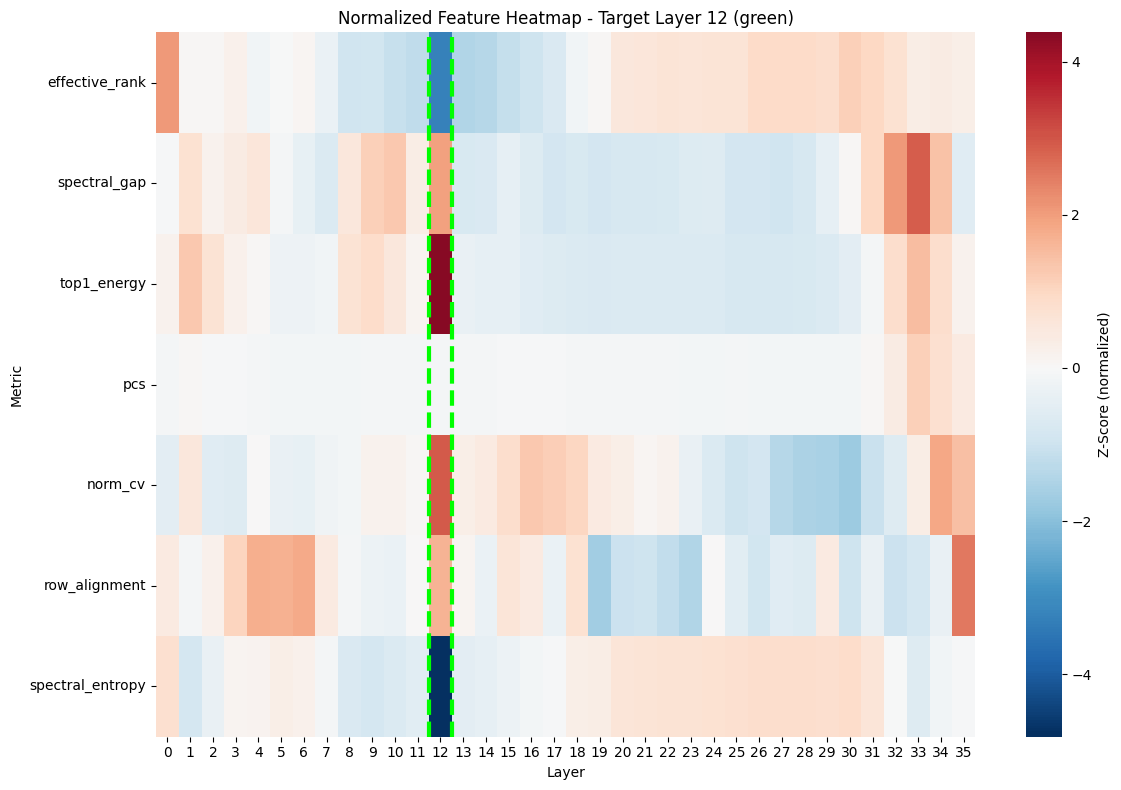


--- Target Layer 12 Z-Scores ---
  effective_rank: -3.239 ⚠️ OUTLIER
  spectral_gap: +1.973 
  top1_energy: +4.383 ⚠️ OUTLIER
  pcs: -0.087 
  norm_cv: +2.913 ⚠️ OUTLIER
  row_alignment: +1.676 
  spectral_entropy: -4.816 ⚠️ OUTLIER


In [83]:
# Comprehensive heatmap of blind detection features
if blind and 'layer_features' in blind:
    # Normalize features for comparison
    df_norm = (df_layers - df_layers.mean()) / (df_layers.std() + 1e-10)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Create heatmap with target layer highlighted
    mask = np.zeros_like(df_norm.values)
    hm = sns.heatmap(df_norm.T, cmap='RdBu_r', center=0, annot=False, 
                      xticklabels=df_norm.index, yticklabels=df_norm.columns, ax=ax,
                      cbar_kws={'label': 'Z-Score (normalized)'})
    
    # Highlight target layer column
    ax.axvline(x=list(df_norm.index).index(target_layer), color='lime', linewidth=3, linestyle='--')
    ax.axvline(x=list(df_norm.index).index(target_layer)+1, color='lime', linewidth=3, linestyle='--')
    
    ax.set_xlabel('Layer')
    ax.set_ylabel('Metric')
    ax.set_title(f'Normalized Feature Heatmap - Target Layer {target_layer} (green)')
    plt.tight_layout()
    plt.show()
    
    # Z-score summary for target layer
    print(f"\n--- Target Layer {target_layer} Z-Scores ---")
    for col in df_norm.columns:
        z = df_norm.loc[target_layer, col]
        if not np.isnan(z):
            flag = "⚠️ OUTLIER" if abs(z) > 2 else ""
            print(f"  {col}: {z:+.3f} {flag}")

## 6. Outlier Neuron Analysis

In [84]:
# Outlier neuron comparison: baseline vs post-edit
if baseline_blind and case_blind:
    print("=== OUTLIER NEURON ANALYSIS ===\n")
    
    baseline_outliers = set(baseline_blind.get('outlier_neuron_indices', []))
    post_outliers = set(case_blind.get('outlier_neuron_indices', []))
    
    new_outliers = post_outliers - baseline_outliers
    removed_outliers = baseline_outliers - post_outliers
    persistent_outliers = baseline_outliers & post_outliers
    
    print(f"Baseline outlier count: {len(baseline_outliers)}")
    print(f"Post-edit outlier count: {len(post_outliers)}")
    print(f"Baseline outlier fraction: {baseline_blind.get('outlier_neuron_fraction', 0):.4f}")
    print(f"Post-edit outlier fraction: {case_blind.get('outlier_neuron_fraction', 0):.4f}")
    
    print(f"\n--- Outlier Changes ---")
    print(f"New outliers after edit: {len(new_outliers)}")
    print(f"Outliers removed after edit: {len(removed_outliers)}")
    print(f"Persistent outliers: {len(persistent_outliers)}")
    
    if new_outliers:
        print(f"\nNew outlier indices (first 20): {sorted(list(new_outliers))[:20]}")
    
    # Rank recovery comparison
    baseline_rr = baseline_blind.get('rank_recovery', 0)
    post_rr = case_blind.get('rank_recovery', 0)
    print(f"\n--- Rank Recovery ---")
    print(f"Baseline: {baseline_rr:.4f}")
    print(f"Post-edit: {post_rr:.4f}")
    print(f"Change: {post_rr - baseline_rr:+.4f}")

=== OUTLIER NEURON ANALYSIS ===

Baseline outlier count: 0
Post-edit outlier count: 0
Baseline outlier fraction: 0.0000
Post-edit outlier fraction: 0.0000

--- Outlier Changes ---
New outliers after edit: 0
Outliers removed after edit: 0
Persistent outliers: 0

--- Rank Recovery ---
Baseline: 0.0000
Post-edit: 0.0000
Change: +0.0000


## 7. Consistency Anomalies

In [85]:
# Consistency anomalies: which layers have unusual metrics
if case_blind and 'consistency_anomalies' in case_blind:
    print("=== CONSISTENCY ANOMALIES ===\n")
    print(f"Consistency score: {case_blind.get('consistency_score', 0):.4f}")
    print(f"Is likely modified: {case_blind.get('is_likely_modified', False)}")
    print(f"Confidence: {case_blind.get('confidence', 0):.4f}")
    
    anomalies = case_blind['consistency_anomalies']
    if anomalies:
        print(f"\n--- Detected Anomalies ---")
        df_anomalies = pd.DataFrame(anomalies)
        display(df_anomalies)
        
        # Check if target layer is among anomalies
        anomaly_layers = [a['layer'] for a in anomalies]
        if target_layer in anomaly_layers:
            print(f"\n✓ Target layer {target_layer} is in anomaly list")
        else:
            print(f"\n✗ Target layer {target_layer} is NOT in anomaly list")
            print(f"  Anomaly layers: {anomaly_layers}")
    else:
        print("\nNo consistency anomalies detected")
else:
    print("No consistency anomaly data available")

No consistency anomaly data available


## 8. Radar Chart: Target Layer Profile

Using 5 metrics: ['effective_rank', 'spectral_gap', 'top1_energy', 'pcs', 'norm_cv']


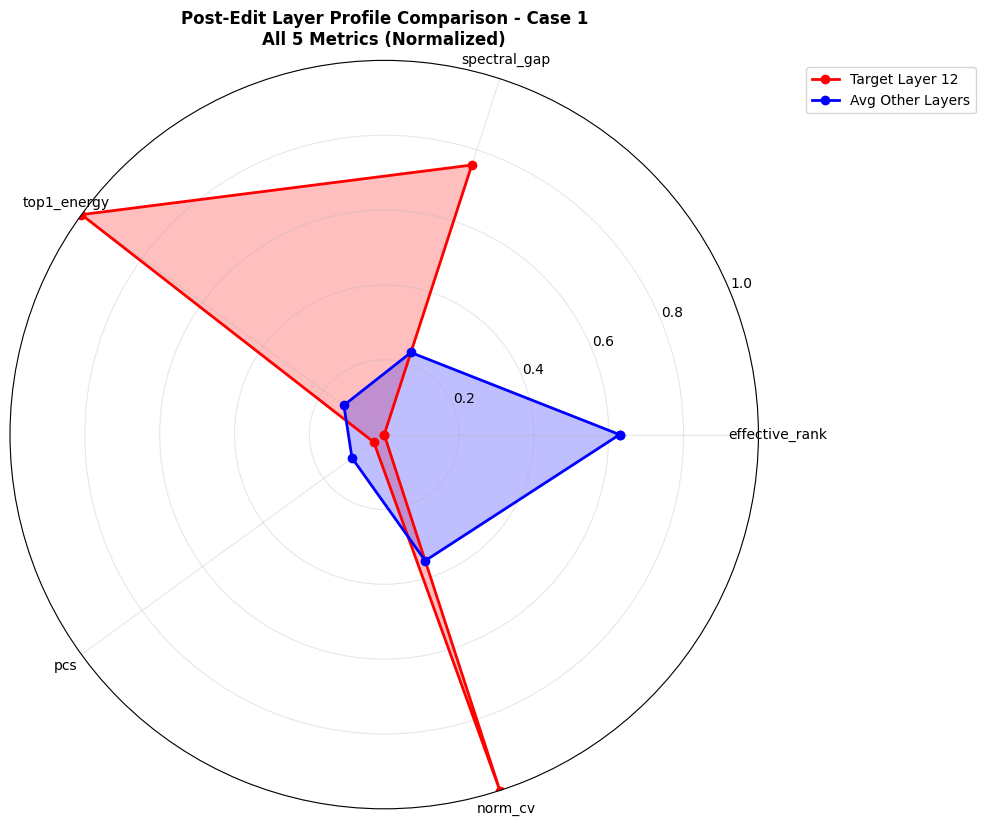

In [86]:
# Radar chart comparing target layer to average of other layers - ALL METRICS
if blind and 'layer_features' in blind:
    from math import pi
    
    # Get ALL available metrics from the dataframe
    metrics = [col for col in df_layers.columns if col in ['effective_rank', 'spectral_gap', 'top1_energy', 'norm_cv', 'pcs']]
    print(f"Using {len(metrics)} metrics: {metrics}")
    
    # Get normalized values
    target_vals = []
    avg_other_vals = []
    
    for m in metrics:
        col = df_layers[m].replace([np.inf, -np.inf], np.nan).dropna()
        if len(col) == 0:
            target_vals.append(0)
            avg_other_vals.append(0)
            continue
            
        # Normalize to 0-1 range
        min_val, max_val = col.min(), col.max()
        if max_val - min_val < 1e-10:
            normalized = col * 0  # All same value, normalize to 0
        else:
            normalized = (col - min_val) / (max_val - min_val)
        
        target_vals.append(normalized.loc[target_layer] if target_layer in normalized.index else 0)
        other_vals = normalized.loc[normalized.index != target_layer]
        avg_other_vals.append(other_vals.mean() if len(other_vals) > 0 else 0)
    
    # Close the radar chart
    target_vals += target_vals[:1]
    avg_other_vals += avg_other_vals[:1]
    metrics_plot = metrics + metrics[:1]
    
    # Create radar chart
    angles = [n / float(len(metrics)) * 2 * pi for n in range(len(metrics))]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    ax.plot(angles, target_vals, 'o-', linewidth=2, label=f'Target Layer {target_layer}', color='red')
    ax.fill(angles, target_vals, alpha=0.25, color='red')
    
    ax.plot(angles, avg_other_vals, 'o-', linewidth=2, label='Avg Other Layers', color='blue')
    ax.fill(angles, avg_other_vals, alpha=0.25, color='blue')
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=10)
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    ax.set_title(f'Post-Edit Layer Profile Comparison - Case {SELECTED_CASE_ID}\nAll {len(metrics)} Metrics (Normalized)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


=== ALL LAYERS BASELINE vs POST-EDIT COMPARISON ===
Showing 36 layers with 5 metrics each


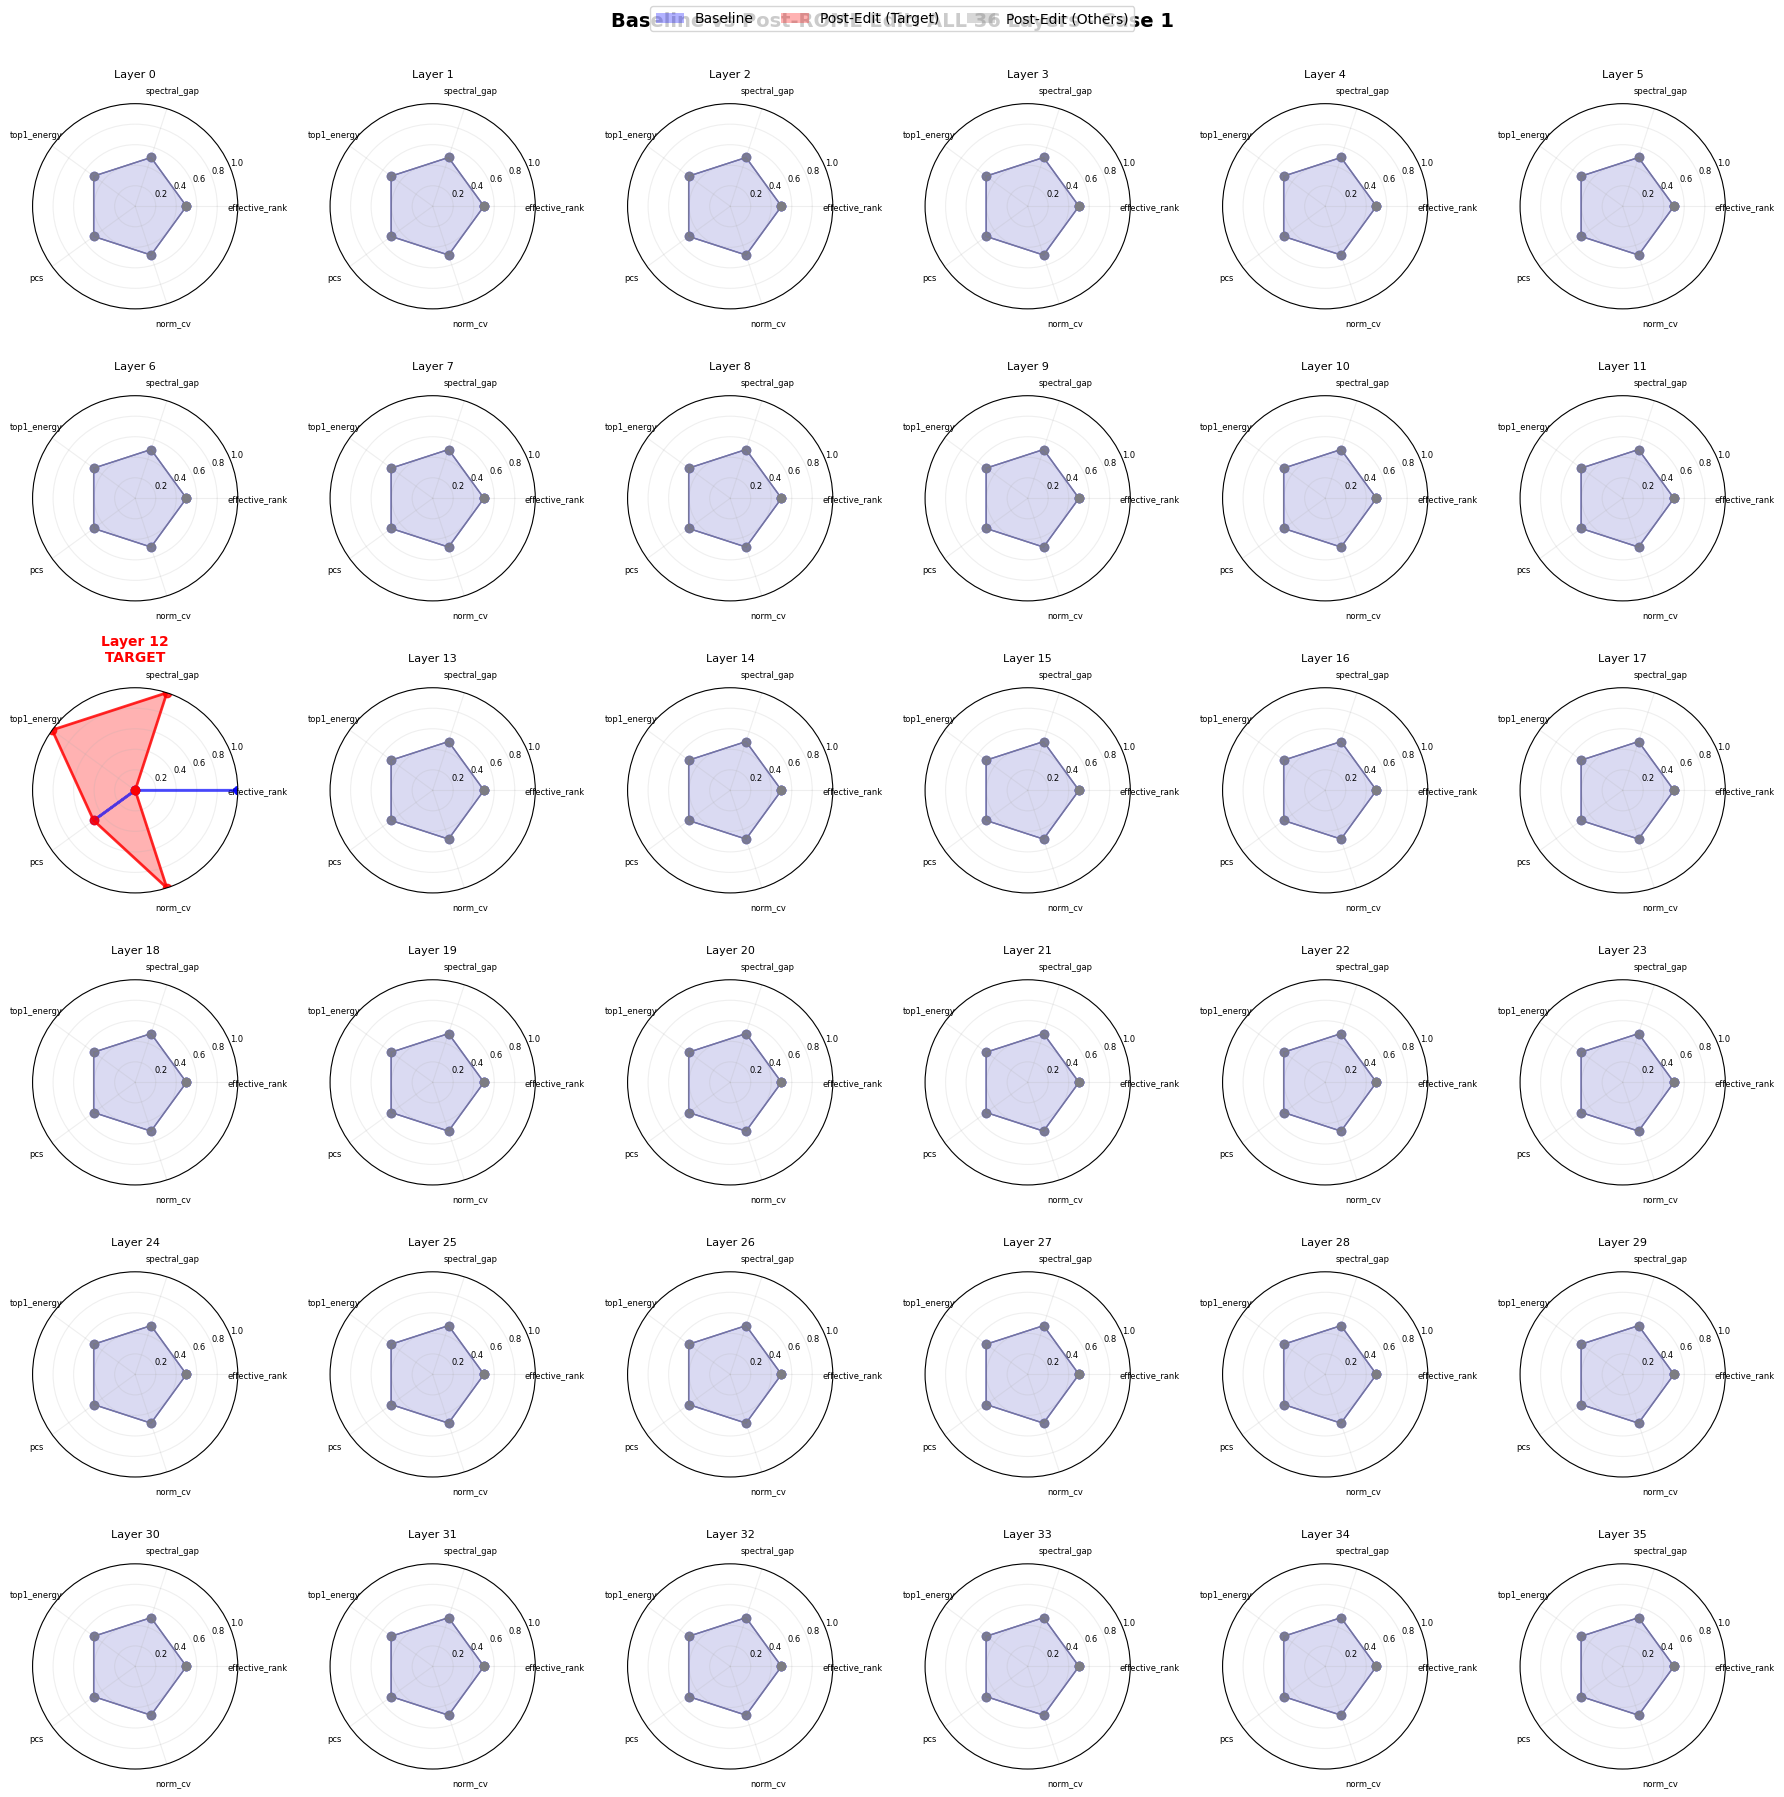

In [87]:
# Radar charts: ALL Layers Baseline vs Post-Edit (Grid View)
if baseline_blind and case_blind and 'layer_features' in baseline_blind and 'layer_features' in case_blind:
    from math import pi
    
    # Get ALL available metrics
    metrics = [col for col in df_baseline.columns if col in ['effective_rank', 'spectral_gap', 'top1_energy', 'norm_cv', 'pcs']]
    
    # Get all layers
    all_layers = sorted(df_baseline.index.tolist())
    print(f"\n=== ALL LAYERS BASELINE vs POST-EDIT COMPARISON ===")
    print(f"Showing {len(all_layers)} layers with {len(metrics)} metrics each")
    
    # Create grid of radar charts (4x6 for 24 layers)
    n_cols = 6
    n_rows = (len(all_layers) + n_cols - 1) // n_cols
    
    fig = plt.figure(figsize=(18, 3*n_rows))
    
    for idx, layer in enumerate(all_layers):
        ax = plt.subplot(n_rows, n_cols, idx+1, projection='polar')
        
        # Get values for this layer
        baseline_vals_raw = []
        post_vals_raw = []
        
        for m in metrics:
            baseline_val = df_baseline.loc[layer, m] if layer in df_baseline.index else np.nan
            post_val = df_post.loc[layer, m] if layer in df_post.index else np.nan
            
            # Handle inf/nan
            if np.isinf(baseline_val) or np.isnan(baseline_val):
                baseline_val = 0
            if np.isinf(post_val) or np.isnan(post_val):
                post_val = 0
                
            baseline_vals_raw.append(baseline_val)
            post_vals_raw.append(post_val)
        
        # Normalize each metric
        baseline_vals_norm = []
        post_vals_norm = []
        
        for i in range(len(metrics)):
            min_val = min(baseline_vals_raw[i], post_vals_raw[i])
            max_val = max(baseline_vals_raw[i], post_vals_raw[i])
            
            if max_val - min_val < 1e-10:
                baseline_vals_norm.append(0.5)
                post_vals_norm.append(0.5)
            else:
                baseline_vals_norm.append((baseline_vals_raw[i] - min_val) / (max_val - min_val))
                post_vals_norm.append((post_vals_raw[i] - min_val) / (max_val - min_val))
        
        # Close the radar chart
        baseline_vals_norm += baseline_vals_norm[:1]
        post_vals_norm += post_vals_norm[:1]
        
        # Create angles
        angles = [n / float(len(metrics)) * 2 * pi for n in range(len(metrics))]
        angles += angles[:1]
        
        # Plot
        color = 'red' if layer == target_layer else 'gray'
        linewidth = 2 if layer == target_layer else 1
        alpha_fill = 0.3 if layer == target_layer else 0.1
        
        ax.plot(angles, baseline_vals_norm, 'o-', linewidth=linewidth, color='blue', alpha=0.6)
        ax.fill(angles, baseline_vals_norm, alpha=alpha_fill, color='blue')
        
        ax.plot(angles, post_vals_norm, 'o-', linewidth=linewidth, color=color, alpha=0.8)
        ax.fill(angles, post_vals_norm, alpha=alpha_fill, color=color)
        
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(metrics, fontsize=6)
        ax.set_ylim(0, 1)
        
        # Title with emphasis on target layer
        if layer == target_layer:
            ax.set_title(f'Layer {layer}\n TARGET ', fontsize=10, fontweight='bold', color='red')
        else:
            ax.set_title(f'Layer {layer}', fontsize=8)
        
        ax.grid(True, alpha=0.2)
        ax.tick_params(labelsize=6)
    
    # Add legend to the figure
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='blue', alpha=0.3, label='Baseline'),
        Patch(facecolor='red', alpha=0.3, label='Post-Edit (Target)'),
        Patch(facecolor='gray', alpha=0.3, label='Post-Edit (Others)')
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=3, fontsize=10)
    
    plt.suptitle(f'Baseline vs Post-ROME Edit: ALL {len(all_layers)} Layers - Case {SELECTED_CASE_ID}', 
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()
else:
    print("Baseline or post-edit data not available for all layers comparison")

## 9. Singular Value Analysis - Rank-One Structure

=== SINGULAR VALUE ANALYSIS ===

σ₁/σ₂ Ratio: Mean=5280074, Min=3461951, Max=7228645
Effective Rank: Mean=1.000, Std=0.000
Rank-One Score: Mean=1.000000, Min=1.000000


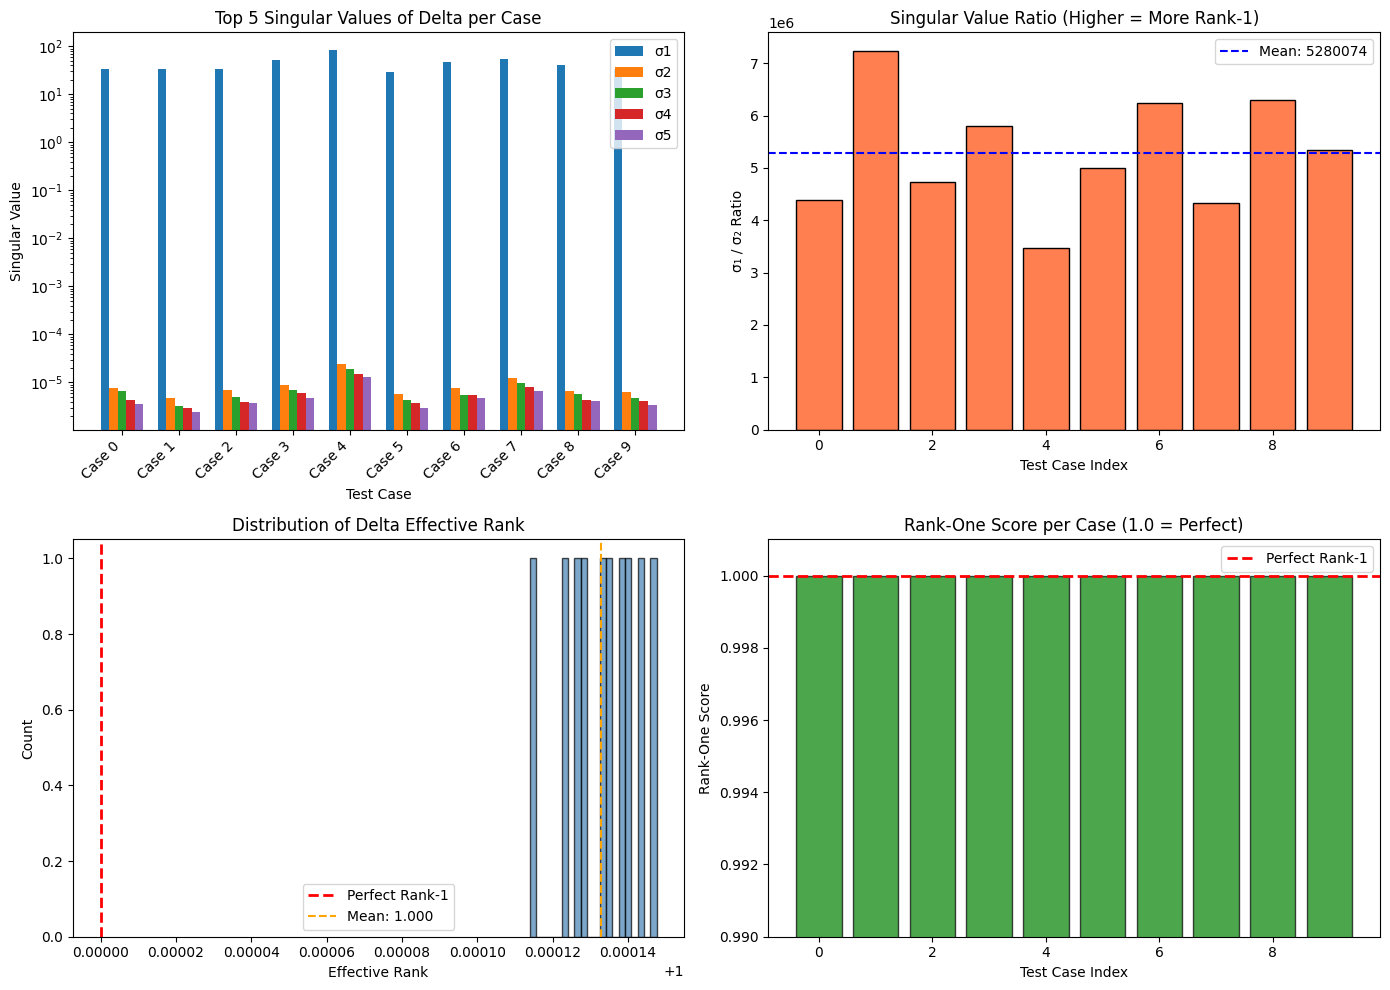

In [88]:
# Singular Value Analysis - Compare top singular values across cases
print("=== SINGULAR VALUE ANALYSIS ===\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Top singular values bar chart per case
ax1 = axes[0, 0]
case_labels = []
sv_data = []
for test in data['tests']:
    if test.get('error') or 'normal_detection' not in test:
        continue
    svs = test['normal_detection'].get('top_singular_values', [])
    if svs:
        case_labels.append(f"Case {test['case_id']}")
        sv_data.append(svs[:5])  # Top 5 SVs

if sv_data:
    sv_array = np.array(sv_data)
    x = np.arange(len(case_labels))
    width = 0.15
    for i in range(min(5, sv_array.shape[1])):
        ax1.bar(x + i*width, sv_array[:, i], width, label=f'σ{i+1}')
    ax1.set_xlabel('Test Case')
    ax1.set_ylabel('Singular Value')
    ax1.set_title('Top 5 Singular Values of Delta per Case')
    ax1.set_xticks(x + 2*width)
    ax1.set_xticklabels(case_labels, rotation=45, ha='right')
    ax1.legend()
    ax1.set_yscale('log')

# 2. Ratio σ1/σ2 distribution (shows rank-1 structure)
ax2 = axes[0, 1]
ratios = []
for test in data['tests']:
    if test.get('error') or 'normal_detection' not in test:
        continue
    svs = test['normal_detection'].get('top_singular_values', [])
    if len(svs) >= 2 and svs[1] > 1e-10:
        ratios.append(svs[0] / svs[1])

if ratios:
    ax2.bar(range(len(ratios)), ratios, color='coral', edgecolor='black')
    ax2.axhline(y=np.mean(ratios), color='blue', linestyle='--', label=f'Mean: {np.mean(ratios):.0f}')
    ax2.set_xlabel('Test Case Index')
    ax2.set_ylabel('σ₁ / σ₂ Ratio')
    ax2.set_title('Singular Value Ratio (Higher = More Rank-1)')
    ax2.legend()
    print(f"σ₁/σ₂ Ratio: Mean={np.mean(ratios):.0f}, Min={np.min(ratios):.0f}, Max={np.max(ratios):.0f}")

# 3. Effective rank distribution
ax3 = axes[1, 0]
eff_ranks = []
for test in data['tests']:
    if test.get('error') or 'normal_detection' not in test:
        continue
    er = test['normal_detection'].get('effective_rank', 0)
    if er > 0:
        eff_ranks.append(er)

if eff_ranks:
    ax3.hist(eff_ranks, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    ax3.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Perfect Rank-1')
    ax3.axvline(x=np.mean(eff_ranks), color='orange', linestyle='--', label=f'Mean: {np.mean(eff_ranks):.3f}')
    ax3.set_xlabel('Effective Rank')
    ax3.set_ylabel('Count')
    ax3.set_title('Distribution of Delta Effective Rank')
    ax3.legend()
    print(f"Effective Rank: Mean={np.mean(eff_ranks):.3f}, Std={np.std(eff_ranks):.3f}")

# 4. Rank-one score distribution
ax4 = axes[1, 1]
ro_scores = []
for test in data['tests']:
    if test.get('error') or 'normal_detection' not in test:
        continue
    ros = test['normal_detection'].get('rank_one_score', 0)
    if ros > 0:
        ro_scores.append(ros)

if ro_scores:
    ax4.bar(range(len(ro_scores)), ro_scores, color='green', edgecolor='black', alpha=0.7)
    ax4.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Perfect Rank-1')
    ax4.set_xlabel('Test Case Index')
    ax4.set_ylabel('Rank-One Score')
    ax4.set_title('Rank-One Score per Case (1.0 = Perfect)')
    ax4.set_ylim(0.99, 1.001)
    ax4.legend()
    print(f"Rank-One Score: Mean={np.mean(ro_scores):.6f}, Min={np.min(ro_scores):.6f}")

plt.tight_layout()
plt.show()

## 10. ROME Parameter Correlation Analysis

=== ROME PARAMETER CORRELATION ANALYSIS ===



/tmp/ipykernel_316708/1382822088.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([success_delta, fail_delta] if len(fail_delta) > 0 else [success_delta],


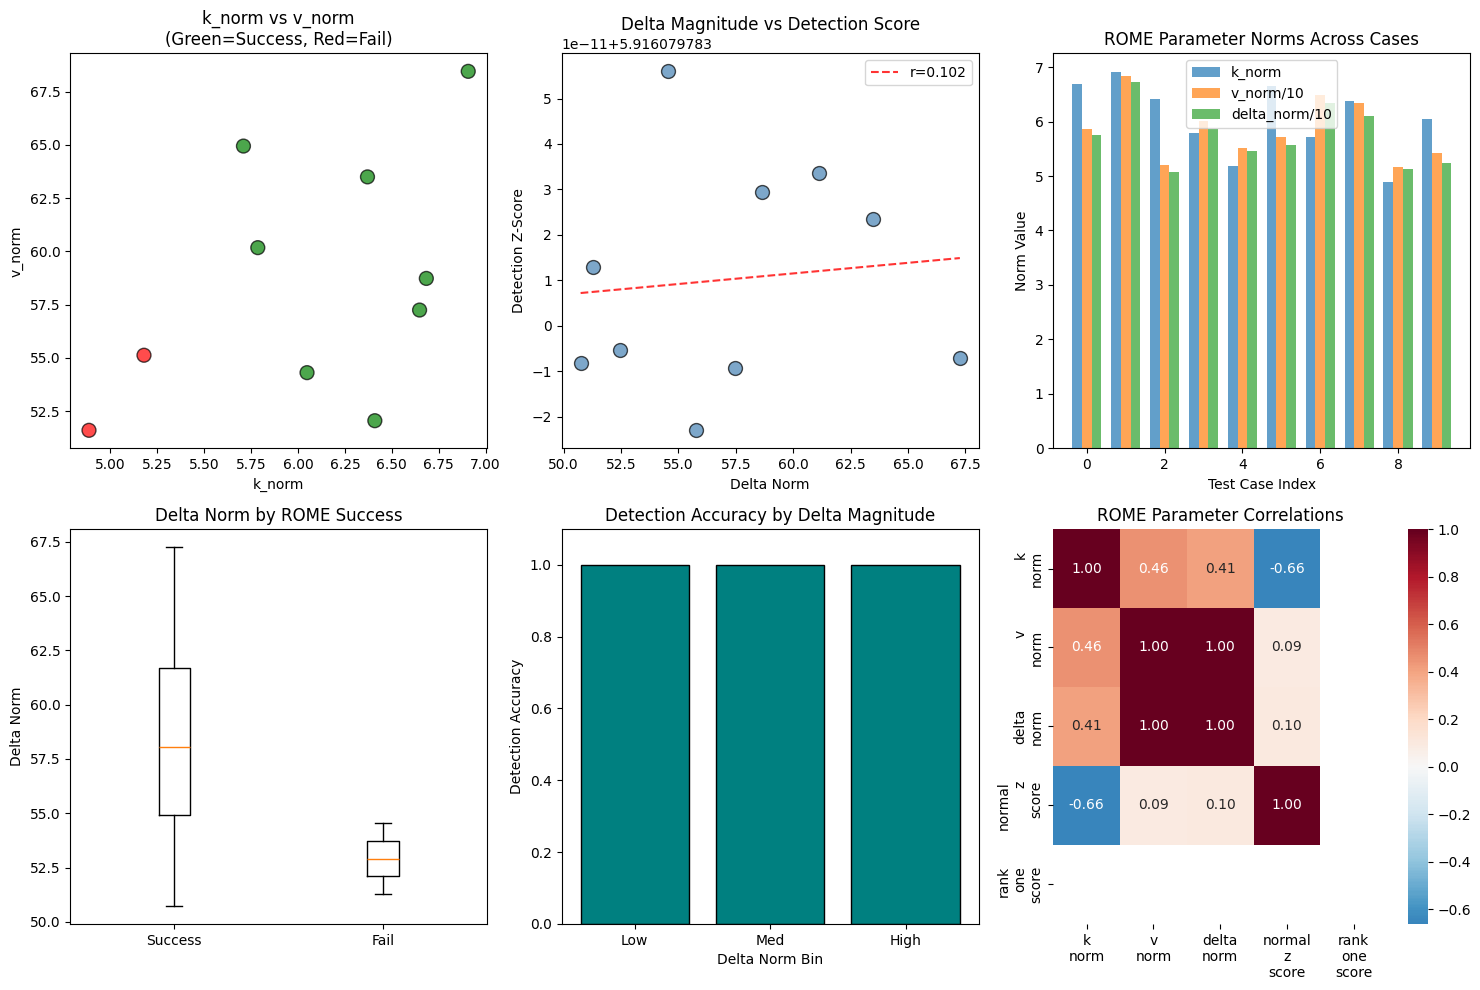


--- ROME Parameter Statistics ---
          k_norm     v_norm  delta_norm  normal_z_score
count  10.000000  10.000000   10.000000    1.000000e+01
mean    6.062908  58.610461   57.272534    5.916080e+00
std     0.668404   5.656353    5.441227    2.486642e-11
min     4.886627  51.598537   50.735569    5.916080e+00
25%     5.728669  54.509589   52.959700    5.916080e+00
50%     6.209346  57.985928   56.626308    5.916080e+00
75%     6.588348  62.664289   60.488647    5.916080e+00
max     6.907140  68.448502   67.260872    5.916080e+00


In [89]:
# ROME Parameter Correlation - How do k, v, delta norms relate to detection?
print("=== ROME PARAMETER CORRELATION ANALYSIS ===\n")

# Collect ROME metrics
rome_metrics = []
for test in data['tests']:
    if test.get('error') or 'rome' not in test:
        continue
    rome = test['rome']
    normal = test.get('normal_detection', {})
    
    rome_metrics.append({
        'case_id': test['case_id'],
        'subject': test['subject'][:20],
        'k_norm': rome['k_norm'],
        'v_norm': rome['v_norm'],
        'delta_norm': rome['delta_norm'],
        'rome_success': rome['success'],
        'normal_z_score': normal.get('layer_z_score', 0),
        'rank_one_score': normal.get('rank_one_score', 0),
        'normal_correct': normal.get('anomalous_layer') == target_layer,
        'blind_correct': test.get('blind_detection', {}).get('anomalous_layer') == target_layer,
    })

df_rome = pd.DataFrame(rome_metrics)

if len(df_rome) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # 1. k_norm vs v_norm scatter
    ax = axes[0, 0]
    colors = ['green' if s else 'red' for s in df_rome['rome_success']]
    ax.scatter(df_rome['k_norm'], df_rome['v_norm'], c=colors, s=100, edgecolor='black', alpha=0.7)
    ax.set_xlabel('k_norm')
    ax.set_ylabel('v_norm')
    ax.set_title('k_norm vs v_norm\n(Green=Success, Red=Fail)')
    
    # 2. delta_norm vs Z-score
    ax = axes[0, 1]
    ax.scatter(df_rome['delta_norm'], df_rome['normal_z_score'], c='steelblue', s=100, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Delta Norm')
    ax.set_ylabel('Detection Z-Score')
    ax.set_title('Delta Magnitude vs Detection Score')
    # Add correlation line
    if len(df_rome) > 2:
        z = np.polyfit(df_rome['delta_norm'], df_rome['normal_z_score'], 1)
        p = np.poly1d(z)
        ax.plot(sorted(df_rome['delta_norm']), p(sorted(df_rome['delta_norm'])), 
                "r--", alpha=0.8, label=f'r={np.corrcoef(df_rome["delta_norm"], df_rome["normal_z_score"])[0,1]:.3f}')
        ax.legend()
    
    # 3. ROME norms bar comparison
    ax = axes[0, 2]
    x = range(len(df_rome))
    width = 0.25
    ax.bar([i - width for i in x], df_rome['k_norm'], width, label='k_norm', alpha=0.7)
    ax.bar(x, df_rome['v_norm']/10, width, label='v_norm/10', alpha=0.7)  # Scale for visibility
    ax.bar([i + width for i in x], df_rome['delta_norm']/10, width, label='delta_norm/10', alpha=0.7)
    ax.set_xlabel('Test Case Index')
    ax.set_ylabel('Norm Value')
    ax.set_title('ROME Parameter Norms Across Cases')
    ax.legend()
    
    # 4. Success vs parameter distributions (box plots)
    ax = axes[1, 0]
    success_delta = df_rome[df_rome['rome_success']]['delta_norm']
    fail_delta = df_rome[~df_rome['rome_success']]['delta_norm']
    bp = ax.boxplot([success_delta, fail_delta] if len(fail_delta) > 0 else [success_delta], 
                    labels=['Success', 'Fail'] if len(fail_delta) > 0 else ['Success'])
    ax.set_ylabel('Delta Norm')
    ax.set_title('Delta Norm by ROME Success')
    
    # 5. Detection accuracy by delta norm bins
    ax = axes[1, 1]
    if len(df_rome) > 3:
        df_rome['delta_bin'] = pd.qcut(df_rome['delta_norm'], q=min(3, len(df_rome)), labels=['Low', 'Med', 'High'][:min(3, len(df_rome))])
        acc_by_bin = df_rome.groupby('delta_bin')['normal_correct'].mean()
        ax.bar(acc_by_bin.index.astype(str), acc_by_bin.values, color='teal', edgecolor='black')
        ax.set_xlabel('Delta Norm Bin')
        ax.set_ylabel('Detection Accuracy')
        ax.set_title('Detection Accuracy by Delta Magnitude')
        ax.set_ylim(0, 1.1)
    else:
        ax.text(0.5, 0.5, 'Not enough data\nfor binning', ha='center', va='center', transform=ax.transAxes)
    
    # 6. Correlation heatmap
    ax = axes[1, 2]
    numeric_cols = ['k_norm', 'v_norm', 'delta_norm', 'normal_z_score', 'rank_one_score']
    corr_matrix = df_rome[numeric_cols].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, ax=ax, fmt='.2f',
                xticklabels=[c.replace('_', '\n') for c in numeric_cols],
                yticklabels=[c.replace('_', '\n') for c in numeric_cols])
    ax.set_title('ROME Parameter Correlations')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\n--- ROME Parameter Statistics ---")
    print(df_rome[['k_norm', 'v_norm', 'delta_norm', 'normal_z_score']].describe())
else:
    print("No ROME metrics available")

=== INTER-LAYER TRANSITION CHECKS (BLIND FEATURES) ===


-- case_blind --
effective_rank: top transition z-scores -> {12: 3.2062872135291625, 1: 3.1852740751359474, 13: 2.7726195125519504}
spectral_gap: top transition z-scores -> {13: 3.438164255324222, 35: 2.302283238375626, 12: 1.7254065971597958}
top1_energy: top transition z-scores -> {13: 4.038747099038404, 12: 3.6140978906755925, 1: 0.6074119429048935}
pcs: top transition z-scores -> {33: 0.7426085011251421, 34: 0.3015548389094888, 32: 0.29109451188735674}
norm_cv: top transition z-scores -> {12: 3.5378083826702937, 13: 3.1855569249938718, 34: 1.5528421951900526}

-- baseline_blind --
effective_rank: top transition z-scores -> {1: 5.070148380638504, 8: 1.1428460014307065, 18: 0.950207019429613}
spectral_gap: top transition z-scores -> {35: 3.2960199067440383, 34: 2.150702727460922, 8: 1.7020520924733753}
top1_energy: top transition z-scores -> {1: 2.899923217786113, 32: 2.1700896967325933, 8: 1.9477054948932504}
pcs: top transiti

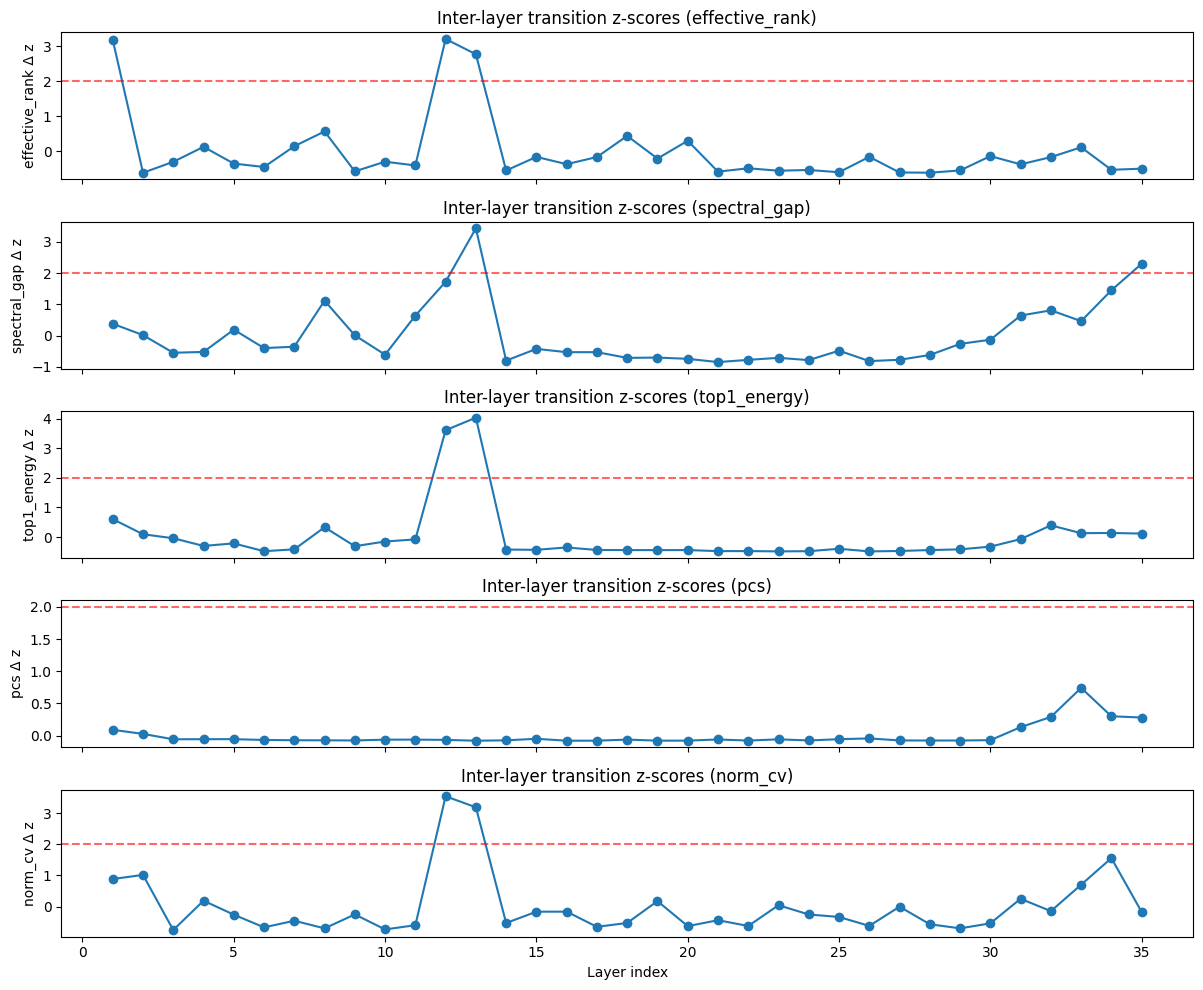

In [90]:
# 12. Blind Feature Transition & Layer-Jump Checks (from analysis_out)
print("=== INTER-LAYER TRANSITION CHECKS (BLIND FEATURES) ===\n")

def layer_features_to_df(layer_features):
    if not layer_features:
        return pd.DataFrame()
    df = pd.DataFrame(layer_features).T
    df.index = df.index.astype(int)
    df = df.sort_index()
    df = df.apply(pd.to_numeric, errors='coerce')
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    return df

metrics = ['effective_rank', 'spectral_gap', 'top1_energy', 'pcs', 'norm_cv']

case_blind = case.get('blind_detection', {})
case_lf = layer_features_to_df(case_blind.get('layer_features', {}))
baseline_lf = layer_features_to_df(data.get('baseline_blind', {}).get('layer_features', {}))

def transition_zscores(df, metric):
    if metric not in df.columns:
        return None
    delta = df[metric].diff().abs().dropna()
    if len(delta) < 3:
        return None
    z = (delta - delta.mean()) / (delta.std() + 1e-10)
    return z

for label, df in [('case_blind', case_lf), ('baseline_blind', baseline_lf)]:
    if df.empty:
        print(f"No layer_features available for {label}")
        continue
    print(f"\n-- {label} --")
    for m in metrics:
        z = transition_zscores(df, m)
        if z is None:
            continue
        top = z.sort_values(ascending=False).head(3)
        print(f"{m}: top transition z-scores -> {top.to_dict()}")

fig, axes = plt.subplots(len(metrics), 1, figsize=(12, 10), sharex=True)
for i, m in enumerate(metrics):
    ax = axes[i]
    z = transition_zscores(case_lf, m) if not case_lf.empty else None
    if z is None:
        ax.text(0.5, 0.5, f'No data for {m}', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        continue
    ax.plot(z.index, z.values, marker='o')
    ax.axhline(2.0, color='red', linestyle='--', alpha=0.6)
    ax.set_ylabel(f"{m} Δ z")
    ax.set_title(f"Inter-layer transition z-scores ({m})")
ax.set_xlabel("Layer index")
plt.tight_layout()
plt.show()

In [91]:
# 13. Cross-layer Consistency Anomalies Summary
print("=== CONSISTENCY ANOMALIES SUMMARY ===\n")

rows = []
baseline = data.get('baseline_blind', {})
for a in baseline.get('consistency_anomalies', []):
    rows.append({**a, 'source': 'baseline_blind'})

for test in data.get('tests', []):
    blind = test.get('blind_detection', {})
    for a in blind.get('consistency_anomalies', []):
        row = {**a, 'source': f"case_{test.get('case_id')}_blind"}
        rows.append(row)

if rows:
    df_consistency = pd.DataFrame(rows)
    display(df_consistency.head(10))
    print("\nTop anomalous layers (frequency):")
    display(df_consistency['layer'].value_counts().head(10))
    print("\nTop anomalous metrics (frequency):")
    display(df_consistency['metric'].value_counts())
else:
    print("No consistency anomalies reported in analysis_out.")

=== CONSISTENCY ANOMALIES SUMMARY ===

No consistency anomalies reported in analysis_out.


## 12. Neuron Group Analysis - Which Groups Change Most?

=== NEURON GROUP CHANGE ANALYSIS ===



/tmp/ipykernel_316708/2162254685.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_groups, x='group', y='score', order=group_order, ax=ax, palette='viridis')
/tmp/ipykernel_316708/2162254685.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


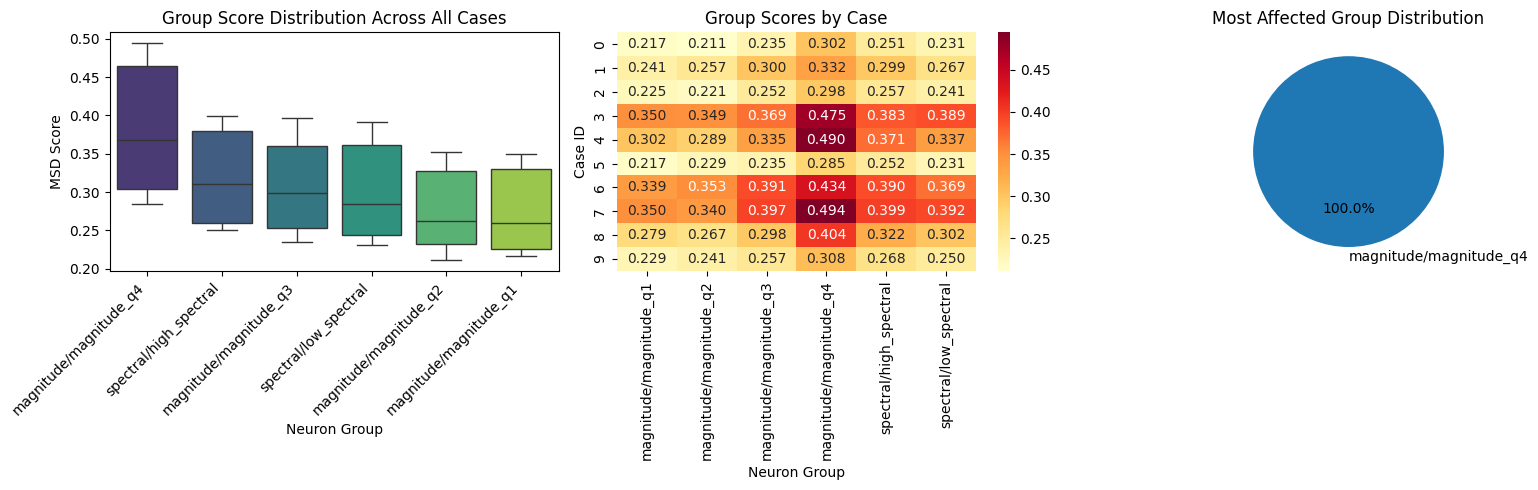


--- Group Score Statistics ---


,mean,std,min,max
group,,,,
magnitude/magnitude_q4,0.382334,0.086324,0.284885,0.494290
spectral/high_spectral,0.319022,0.061636,0.250979,0.398818
magnitude/magnitude_q3,0.306889,0.063152,0.234863,0.396721
spectral/low_spectral,0.300937,0.065771,0.231126,0.391756
magnitude/magnitude_q2,0.275783,0.054301,0.211427,0.352821
magnitude/magnitude_q1,0.274913,0.056281,0.216549,0.350333


In [92]:
# Neuron Group Analysis - Aggregate across all cases
print("=== NEURON GROUP CHANGE ANALYSIS ===\n")

group_data = []
for test in data['tests']:
    if test.get('error') or 'normal_detection' not in test:
        continue
    normal = test['normal_detection']
    if 'group_scores' in normal:
        for group_name, score in normal['group_scores'].items():
            group_data.append({
                'case_id': test['case_id'],
                'group': group_name,
                'score': score,
                'rome_success': test.get('rome', {}).get('success', False),
            })

if group_data:
    df_groups = pd.DataFrame(group_data)
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # 1. Box plot of group scores
    ax = axes[0]
    group_order = df_groups.groupby('group')['score'].mean().sort_values(ascending=False).index
    sns.boxplot(data=df_groups, x='group', y='score', order=group_order, ax=ax, palette='viridis')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_xlabel('Neuron Group')
    ax.set_ylabel('MSD Score')
    ax.set_title('Group Score Distribution Across All Cases')
    
    # 2. Heatmap of group scores per case
    ax = axes[1]
    pivot_df = df_groups.pivot(index='case_id', columns='group', values='score')
    sns.heatmap(pivot_df, cmap='YlOrRd', annot=True, fmt='.3f', ax=ax)
    ax.set_title('Group Scores by Case')
    ax.set_xlabel('Neuron Group')
    ax.set_ylabel('Case ID')
    
    # 3. Most affected group distribution
    ax = axes[2]
    most_affected = []
    for test in data['tests']:
        if test.get('error') or 'normal_detection' not in test:
            continue
        ma = test['normal_detection'].get('most_affected_group', 'unknown')
        most_affected.append(ma)
    
    if most_affected:
        ma_counts = pd.Series(most_affected).value_counts()
        ax.pie(ma_counts.values, labels=ma_counts.index, autopct='%1.1f%%', startangle=90)
        ax.set_title('Most Affected Group Distribution')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n--- Group Score Statistics ---")
    summary = df_groups.groupby('group')['score'].agg(['mean', 'std', 'min', 'max'])
    display(summary.sort_values('mean', ascending=False))
else:
    print("No group data available")

## 13. Layer Feature Correlation Analysis

**What this shows:** How the blind detection features (computed from SVD of weight matrices) relate to each other.

- **effective_rank**: Entropy-based measure of how many singular values are "active" (low = rank-1 like, high = more distributed)
- **spectral_gap**: Ratio of 1st to 2nd singular value (high = dominant direction)
- **top1_energy**: Fraction of total energy in top singular value (high = rank-1 like)
- **norm_cv**: Coefficient of variation of row norms (high = uneven row magnitudes)

**What to look for:** ROME edits create rank-1 updates, so the target layer should have unusually low effective_rank and high top1_energy/spectral_gap compared to other layers.

=== LAYER FEATURE CORRELATION ANALYSIS ===



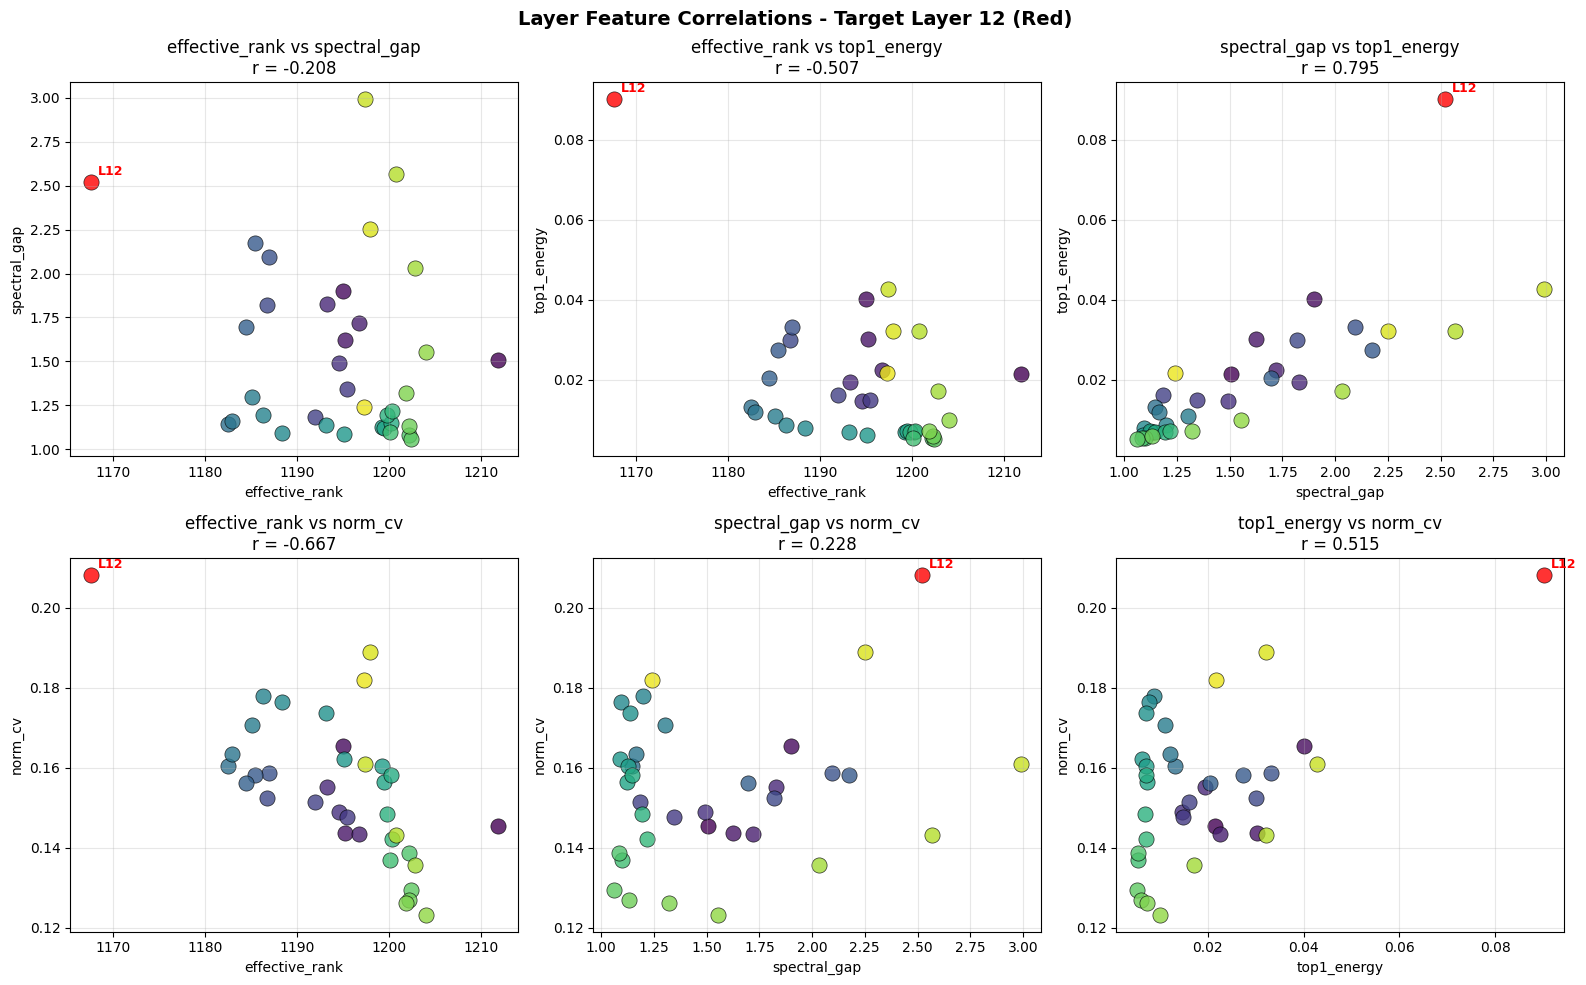


--- Feature Correlation Matrix ---


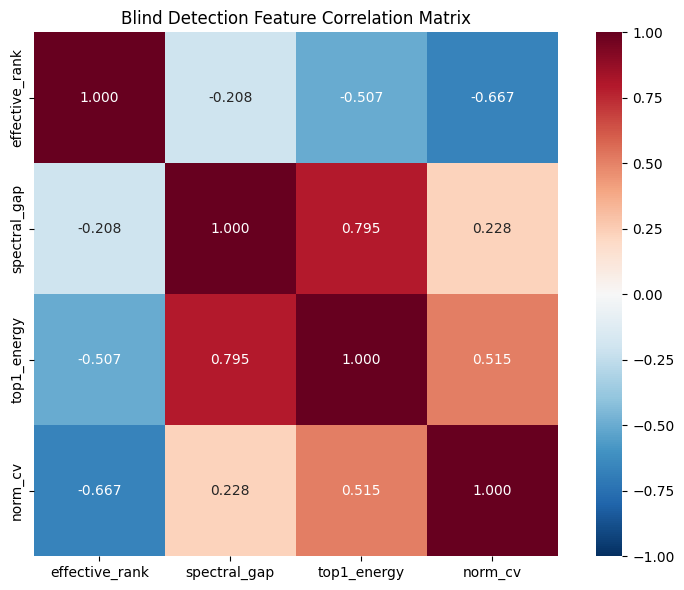

In [ ]:
# Layer Feature Correlation Analysis - WITH EXPLANATIONS
print("=== LAYER FEATURE CORRELATION ANALYSIS ===\n")
print("Each point is one layer. Colors go from purple (early layers) to yellow (late layers).")
print("Target layer (modified by ROME) is marked in RED.\n")

if blind and 'layer_features' in blind:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    # Feature pairs to compare with descriptions
    feature_pairs = [
        ('effective_rank', 'spectral_gap', 'Low eff_rank + High gap = Rank-1 structure'),
        ('effective_rank', 'top1_energy', 'Low eff_rank + High energy = Dominant SV'),
        ('spectral_gap', 'top1_energy', 'Gap vs Energy (should correlate)'),
        ('effective_rank', 'norm_cv', 'Rank structure vs row norm variability'),
        ('spectral_gap', 'norm_cv', 'Spectral gap vs row norm variability'),
        ('top1_energy', 'norm_cv', 'Energy concentration vs row norm variability'),
    ]
    
    for ax, (feat1, feat2, desc) in zip(axes.flatten(), feature_pairs):
        x_vals = df_layers[feat1].replace([np.inf, -np.inf], np.nan)
        y_vals = df_layers[feat2].replace([np.inf, -np.inf], np.nan)
        
        # Color by layer position (viridis: purple->yellow)
        for i, l in enumerate(df_layers.index):
            x, y = x_vals.iloc[i], y_vals.iloc[i]
            if np.isnan(x) or np.isnan(y):
                continue
            if l == target_layer:
                ax.scatter(x, y, c='red', s=200, edgecolor='black', linewidth=2, alpha=1.0, zorder=10, marker='*')
                ax.annotate(f'L{target_layer}\n(TARGET)', (x, y), xytext=(8, 8), textcoords='offset points',
                           fontweight='bold', color='red', fontsize=9,
                           bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8))
            else:
                color = plt.cm.viridis(l / len(df_layers))
                ax.scatter(x, y, c=[color], s=100, edgecolor='black', linewidth=0.5, alpha=0.7)
                ax.annotate(f'{l}', (x, y), xytext=(3, 3), textcoords='offset points', fontsize=7, alpha=0.6)
        
        # Add correlation coefficient
        valid_mask = ~(x_vals.isna() | y_vals.isna())
        if valid_mask.sum() > 2:
            corr = np.corrcoef(x_vals[valid_mask], y_vals[valid_mask])[0, 1]
            ax.set_title(f'{feat1} vs {feat2}\nr = {corr:.3f}\n({desc})', fontsize=10)
        else:
            ax.set_title(f'{feat1} vs {feat2}\n({desc})', fontsize=10)
        
        ax.set_xlabel(feat1, fontsize=10)
        ax.set_ylabel(feat2, fontsize=10)
        ax.grid(alpha=0.3)
    
    plt.suptitle(f'Layer Feature Correlations - Modified Model\nTarget Layer {target_layer} (Red Star)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Feature correlation matrix with interpretation
    print("\n--- Feature Correlation Matrix ---")
    print("Interpretation: High positive correlation means features measure similar properties.")
    print("ROME edits should make target layer an outlier in multiple correlated features.\n")
    
    feature_cols = ['effective_rank', 'spectral_gap', 'top1_energy', 'norm_cv']
    corr_df = df_layers[feature_cols].replace([np.inf, -np.inf], np.nan).corr()
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr_df, annot=True, cmap='RdBu_r', center=0, ax=ax, fmt='.3f',
                vmin=-1, vmax=1, square=True)
    ax.set_title('Feature Correlation Matrix\n(Strong negative = inverse relationship)')
    plt.tight_layout()
    plt.show()
    
    # Print target layer's position in each metric
    print("\n--- Target Layer Feature Ranks ---")
    print(f"Where does target layer {target_layer} rank among all {len(df_layers)} layers?\n")
    for col in feature_cols:
        vals = df_layers[col].replace([np.inf, -np.inf], np.nan).dropna()
        target_val = df_layers.loc[target_layer, col] if target_layer in df_layers.index else np.nan
        if not np.isnan(target_val):
            rank_asc = (vals < target_val).sum() + 1  # Rank ascending
            rank_desc = (vals > target_val).sum() + 1  # Rank descending
            percentile = 100 * (vals < target_val).sum() / len(vals)
            print(f"  {col}: value={target_val:.4f}, rank={rank_asc}/{len(vals)} (percentile={percentile:.0f}%)")
else:
    print("No layer features available")

## 15. Layer-wise Metric Trends (Line Plot)

=== LAYER-WISE METRIC TRENDS ===



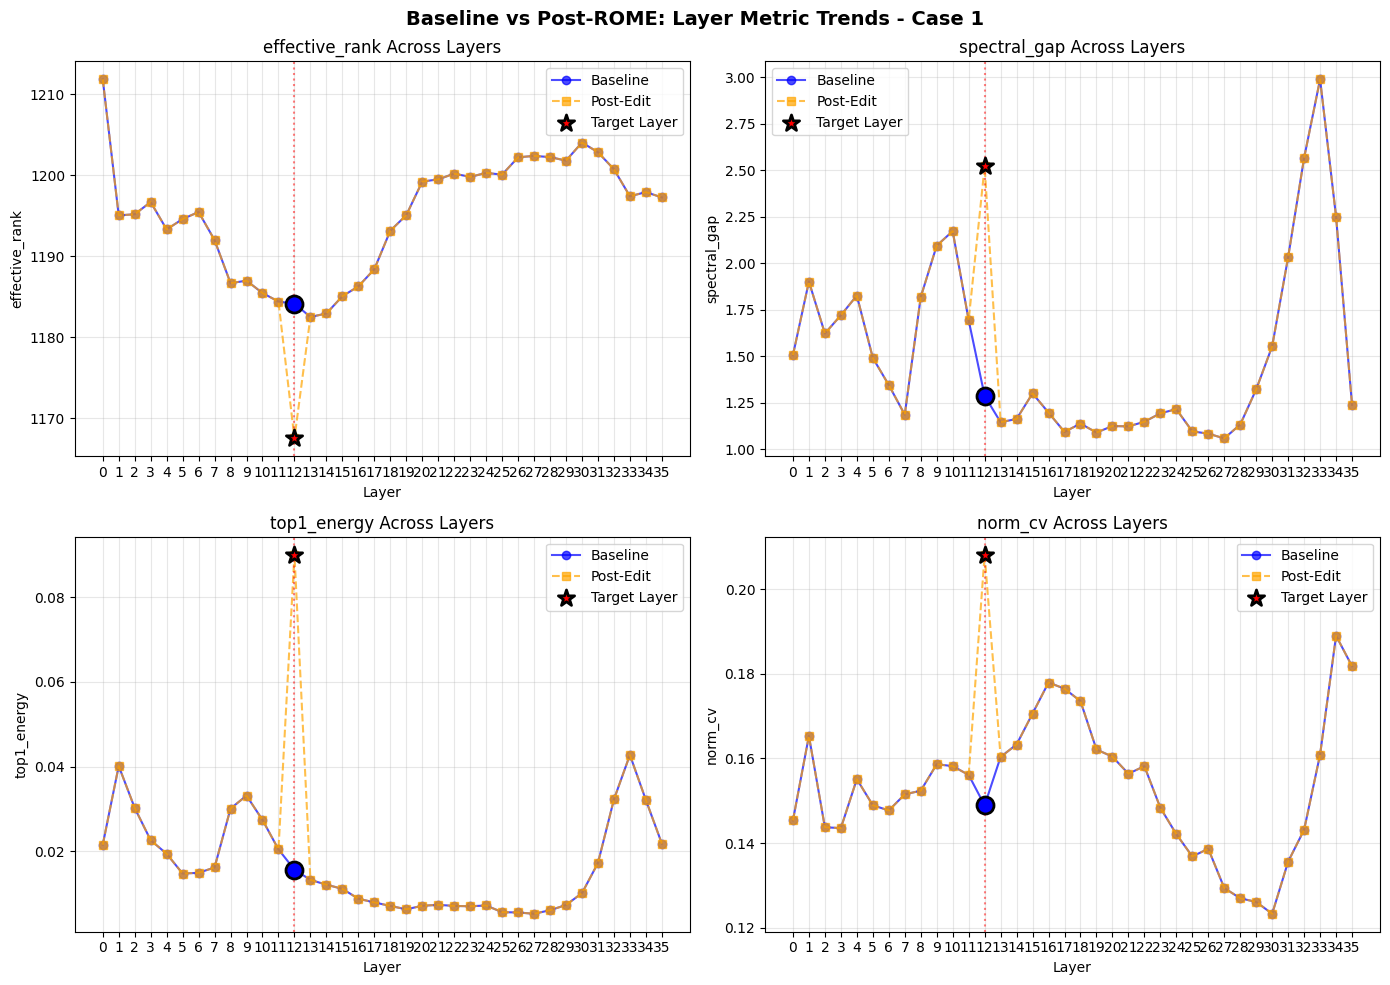

In [94]:
# Layer-wise Metric Trends - Compare baseline vs post-edit as line plots
print("=== LAYER-WISE METRIC TRENDS ===\n")

if 'df_baseline' in dir() and 'df_post' in dir():
    metrics = ['effective_rank', 'spectral_gap', 'top1_energy', 'norm_cv']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    for ax, metric in zip(axes.flatten(), metrics):
        all_layers = sorted(df_baseline.index.tolist())
        
        baseline_vals = [df_baseline.loc[l, metric] if l in df_baseline.index else np.nan for l in all_layers]
        post_vals = [df_post.loc[l, metric] if l in df_post.index else np.nan for l in all_layers]
        
        # Replace inf with nan for plotting
        baseline_vals = [v if not np.isinf(v) else np.nan for v in baseline_vals]
        post_vals = [v if not np.isinf(v) else np.nan for v in post_vals]
        
        ax.plot(all_layers, baseline_vals, 'o-', label='Baseline', color='blue', markersize=6, alpha=0.7)
        ax.plot(all_layers, post_vals, 's--', label='Post-Edit', color='orange', markersize=6, alpha=0.7)
        
        # Highlight target layer
        target_idx = all_layers.index(target_layer)
        if not np.isnan(baseline_vals[target_idx]):
            ax.scatter([target_layer], [baseline_vals[target_idx]], color='blue', s=150, 
                      edgecolor='black', linewidth=2, zorder=5)
        if not np.isnan(post_vals[target_idx]):
            ax.scatter([target_layer], [post_vals[target_idx]], color='red', s=150, 
                      marker='*', edgecolor='black', linewidth=2, zorder=5, label='Target Layer')
        
        ax.axvline(x=target_layer, color='red', linestyle=':', alpha=0.5)
        ax.set_xlabel('Layer')
        ax.set_ylabel(metric)
        ax.set_title(f'{metric} Across Layers')
        ax.legend(loc='best')
        ax.grid(alpha=0.3)
        ax.set_xticks(all_layers)
    
    plt.suptitle(f'Baseline vs Post-ROME: Layer Metric Trends - Case {SELECTED_CASE_ID}', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Baseline or post-edit data not available")

## 16. Case Comparison Dashboard

=== CASE COMPARISON DASHBOARD ===



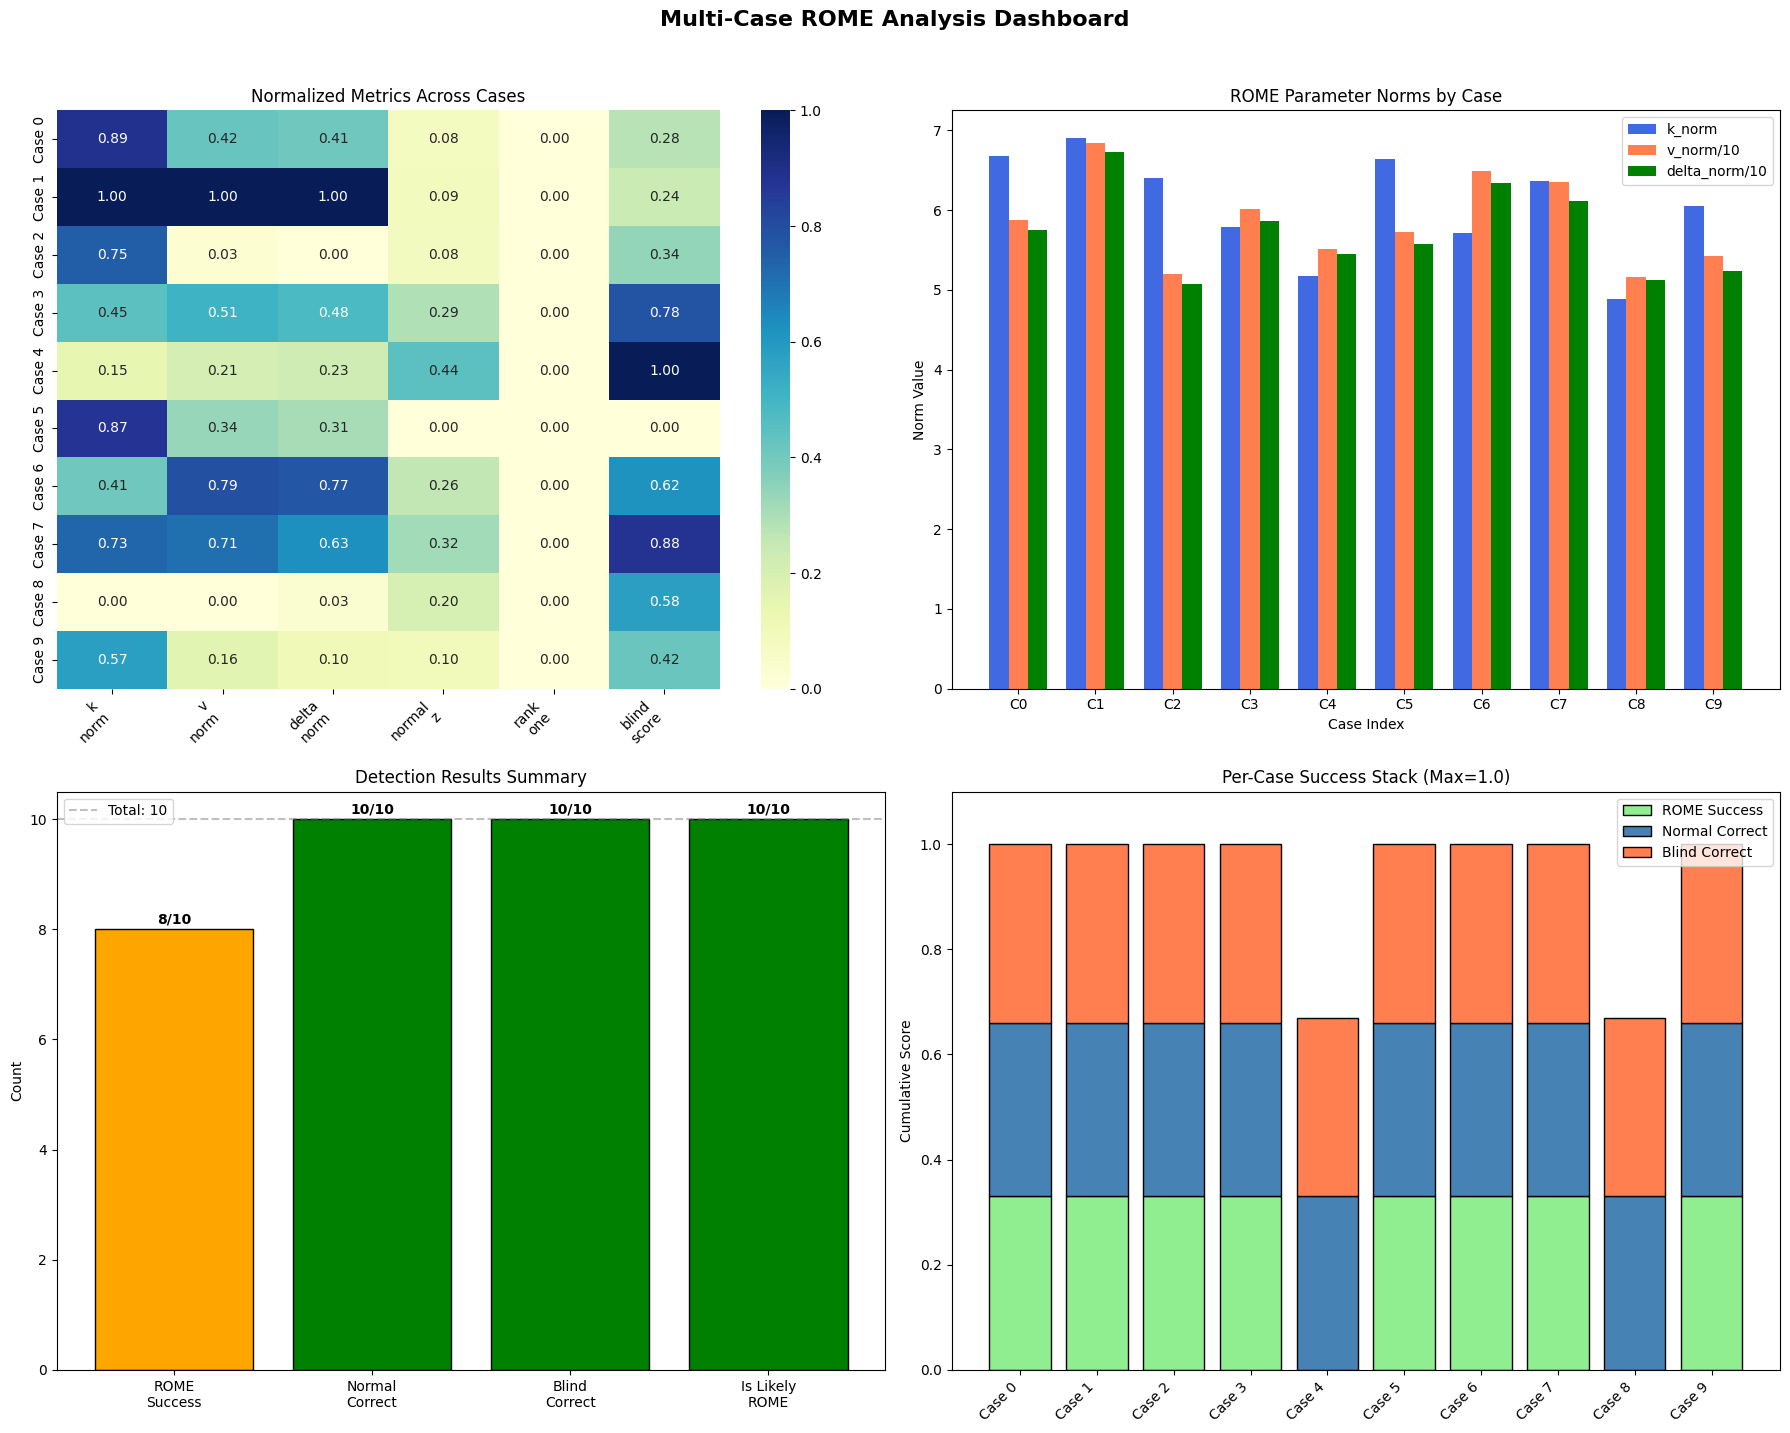


--- Complete Case Summary Table ---


,case_id,subject,rome_success,k_norm,v_norm,delta_norm,normal_z,normal_layer,normal_correct,rank_one,is_likely_rome,blind_layer,blind_correct,blind_score
0,0,Danielle Darrie...,True,6.683909,58.728161,57.475113,5.91608,12,True,1.0,True,12,True,4.838215
1,1,Edwin of Northu...,True,6.907140,68.448502,67.260872,5.91608,12,True,1.0,True,12,True,4.812161
2,2,Toko Yasuda,True,6.409563,52.049686,50.735569,5.91608,12,True,1.0,True,12,True,4.874924
3,3,Autonomous Univ...,True,5.785995,60.172729,58.636200,5.91608,12,True,1.0,True,12,True,5.138886
4,4,Lyon,False,5.179649,55.122566,54.542561,5.91608,12,True,1.0,True,12,True,5.270633
5,5,Thomas Joannes ...,True,6.647943,57.243694,55.777504,5.91608,12,True,1.0,True,12,True,4.669015
6,6,Anaal Nathrakh,True,5.709561,64.940666,63.471695,5.91608,12,True,1.0,True,12,True,5.042275
7,7,Apple A5,True,6.370373,63.494808,61.106129,5.91608,12,True,1.0,True,12,True,5.196909
8,8,Wellington,False,4.886627,51.598537,51.287617,5.91608,12,True,1.0,True,12,True,5.015640
9,9,Shree Pundalik,True,6.048319,54.305264,52.432079,5.91608,12,True,1.0,True,12,True,4.921506


In [95]:
# Case Comparison Dashboard - Overview of all test cases
print("=== CASE COMPARISON DASHBOARD ===\n")

# Collect comprehensive metrics per case
case_metrics = []
for test in data['tests']:
    if test.get('error'):
        continue
    
    rome = test.get('rome', {})
    normal = test.get('normal_detection', {})
    blind = test.get('blind_detection', {})
    
    case_metrics.append({
        'case_id': test['case_id'],
        'subject': test['subject'][:15] + '...' if len(test['subject']) > 15 else test['subject'],
        'rome_success': rome.get('success', False),
        'k_norm': rome.get('k_norm', 0),
        'v_norm': rome.get('v_norm', 0),
        'delta_norm': rome.get('delta_norm', 0),
        'normal_z': normal.get('layer_z_score', 0),
        'normal_layer': normal.get('anomalous_layer', -1),
        'normal_correct': normal.get('anomalous_layer') == target_layer,
        'rank_one': normal.get('rank_one_score', 0),
        'is_likely_rome': normal.get('is_likely_rome', False),
        'blind_layer': blind.get('anomalous_layer', -1),
        'blind_correct': blind.get('anomalous_layer') == target_layer,
        'blind_score': blind.get('layer_anomaly_score', 0),
    })

if case_metrics:
    df_cases = pd.DataFrame(case_metrics)
    
    fig = plt.figure(figsize=(18, 14))
    
    # 1. Overview heatmap (normalized metrics)
    ax1 = plt.subplot(2, 2, 1)
    numeric_cols = ['k_norm', 'v_norm', 'delta_norm', 'normal_z', 'rank_one', 'blind_score']
    norm_df = df_cases[numeric_cols].apply(lambda x: (x - x.min()) / (x.max() - x.min() + 1e-10))
    norm_df.index = [f"Case {c}" for c in df_cases['case_id']]
    sns.heatmap(norm_df, annot=True, cmap='YlGnBu', fmt='.2f', ax=ax1)
    ax1.set_title('Normalized Metrics Across Cases')
    ax1.set_xticklabels([c.replace('_', '\n') for c in numeric_cols], rotation=45, ha='right')
    
    # 2. ROME norms comparison
    ax2 = plt.subplot(2, 2, 2)
    x = np.arange(len(df_cases))
    width = 0.25
    ax2.bar(x - width, df_cases['k_norm'], width, label='k_norm', color='royalblue')
    ax2.bar(x, df_cases['v_norm'] / 10, width, label='v_norm/10', color='coral')  # Scaled
    ax2.bar(x + width, df_cases['delta_norm'] / 10, width, label='delta_norm/10', color='green')
    ax2.set_xlabel('Case Index')
    ax2.set_ylabel('Norm Value')
    ax2.set_title('ROME Parameter Norms by Case')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f"C{c}" for c in df_cases['case_id']])
    ax2.legend()
    
    # 3. Detection results summary
    ax3 = plt.subplot(2, 2, 3)
    detection_summary = {
        'ROME\nSuccess': df_cases['rome_success'].sum(),
        'Normal\nCorrect': df_cases['normal_correct'].sum(),
        'Blind\nCorrect': df_cases['blind_correct'].sum(),
        'Is Likely\nROME': df_cases['is_likely_rome'].sum(),
    }
    colors = ['green' if v == len(df_cases) else 'orange' if v > len(df_cases)/2 else 'red' 
              for v in detection_summary.values()]
    bars = ax3.bar(detection_summary.keys(), detection_summary.values(), color=colors, edgecolor='black')
    ax3.axhline(y=len(df_cases), color='gray', linestyle='--', alpha=0.5, label=f'Total: {len(df_cases)}')
    for bar, v in zip(bars, detection_summary.values()):
        ax3.text(bar.get_x() + bar.get_width()/2, v + 0.1, f'{v}/{len(df_cases)}', 
                ha='center', fontweight='bold')
    ax3.set_ylabel('Count')
    ax3.set_title('Detection Results Summary')
    ax3.legend()
    
    # 4. Detection accuracy stacked bar per case
    ax4 = plt.subplot(2, 2, 4)
    case_labels = [f"Case {c}" for c in df_cases['case_id']]
    
    # Create stacked visualization
    bottom = np.zeros(len(df_cases))
    
    # ROME success (0 or 0.5)
    rome_vals = [0.33 if s else 0 for s in df_cases['rome_success']]
    ax4.bar(case_labels, rome_vals, label='ROME Success', color='lightgreen', edgecolor='black')
    bottom += rome_vals
    
    # Normal correct (0 or 0.5)
    normal_vals = [0.33 if c else 0 for c in df_cases['normal_correct']]
    ax4.bar(case_labels, normal_vals, bottom=bottom, label='Normal Correct', color='steelblue', edgecolor='black')
    bottom += normal_vals
    
    # Blind correct (0 or 0.5)
    blind_vals = [0.34 if c else 0 for c in df_cases['blind_correct']]
    ax4.bar(case_labels, blind_vals, bottom=bottom, label='Blind Correct', color='coral', edgecolor='black')
    
    ax4.set_ylabel('Cumulative Score')
    ax4.set_title('Per-Case Success Stack (Max=1.0)')
    ax4.legend(loc='upper right')
    ax4.set_ylim(0, 1.1)
    plt.xticks(rotation=45, ha='right')
    
    plt.suptitle('Multi-Case ROME Analysis Dashboard', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Print summary table
    print("\n--- Complete Case Summary Table ---")
    display(df_cases)
else:
    print("No case metrics available")

## 17. Final Summary & Key Insights

In [96]:
# Final Summary & Key Insights
print("=" * 70)
print("                 ROME STRUCTURAL METRIC SHIFT ANALYSIS")
print("=" * 70)

# Metadata
print(f"\n📊 EXPERIMENT METADATA")
print(f"   Model: {data['metadata']['model']}")
print(f"   Target Layer: {data['metadata']['target_layer']}")
print(f"   Total Tests: {data['metadata']['n_tests']}")
print(f"   Timestamp: {data['metadata']['timestamp']}")

# Summary statistics
summary = data.get('summary', {})
print(f"\n📈 ROME EDIT RESULTS")
print(f"   ROME Success Rate: {summary.get('rome_success_rate', 0)*100:.1f}%")

# Aggregate statistics (if available)
agg = data.get('aggregate_statistics', {})
if agg:
    print(f"\n📉 ROME PARAMETER STATISTICS")
    rome_norms = agg.get('rome_norms', {})
    print(f"   k_norm: {rome_norms.get('k_mean', 0):.3f} ± {rome_norms.get('k_std', 0):.3f}")
    print(f"   v_norm: {rome_norms.get('v_mean', 0):.3f} ± {rome_norms.get('v_std', 0):.3f}")
    print(f"   delta_norm: {rome_norms.get('delta_mean', 0):.3f} ± {rome_norms.get('delta_std', 0):.3f}")

# Key structural insights
print(f"\n💡 KEY STRUCTURAL INSIGHTS")
valid_tests = [t for t in data['tests'] if not t.get('error')]
if valid_tests:
    # Rank-one analysis
    ro_scores = [t['normal_detection'].get('rank_one_score', 0) for t in valid_tests if 'normal_detection' in t]
    if ro_scores:
        avg_ro = np.mean(ro_scores)
        print(f"   1. ROME edits are highly rank-1: avg rank-one score = {avg_ro:.6f}")
        eff_ranks = [t['normal_detection'].get('effective_rank', 0) for t in valid_tests if 'normal_detection' in t]
        if eff_ranks:
            print(f"      Effective rank of delta: {np.mean(eff_ranks):.3f} ± {np.std(eff_ranks):.3f}")
    
    # Baseline comparison
    baseline_blind = data.get('baseline_blind', {})
    if baseline_blind and 'layer_features' in baseline_blind:
        print(f"   2. Baseline model has {len(baseline_blind.get('layer_features', {}))} layers analyzed")
        baseline_lf = baseline_blind.get('layer_features', {}).get(str(target_layer), {})
        if baseline_lf:
            print(f"      Target layer baseline: eff_rank={baseline_lf.get('effective_rank', 0):.3f}, "
                  f"spectral_gap={baseline_lf.get('spectral_gap', 0):.3f}")
    
    # Metric shift summary across cases
    delta_norms = [t['rome'].get('delta_norm', 0) for t in valid_tests if 'rome' in t]
    if delta_norms:
        print(f"   3. Delta magnitude range: {np.min(delta_norms):.2f} - {np.max(delta_norms):.2f}")
        print(f"      Mean: {np.mean(delta_norms):.2f}, Std: {np.std(delta_norms):.2f}")
    
    # Group analysis
    most_affected = [t['normal_detection'].get('most_affected_group', '') for t in valid_tests if 'normal_detection' in t]
    if most_affected:
        from collections import Counter
        common_group = Counter(most_affected).most_common(1)[0]
        print(f"   4. Most commonly affected group: {common_group[0]} ({common_group[1]}/{len(most_affected)} cases)")
    
    # Interlayer insights
    if 'baseline_interlayer' in data:
        print(f"   5. Interlayer analysis available - compare fingerprints & transitions above")

print("\n" + "=" * 70)
print("                         END OF ANALYSIS")
print("=" * 70)

                 ROME STRUCTURAL METRIC SHIFT ANALYSIS

📊 EXPERIMENT METADATA
   Model: gpt2-large
   Target Layer: 12
   Total Tests: 10
   Timestamp: 2026-01-31T18:40:51.950064

📈 ROME EDIT RESULTS
   ROME Success Rate: 80.0%

💡 KEY STRUCTURAL INSIGHTS
   1. ROME edits are highly rank-1: avg rank-one score = 1.000000
      Effective rank of delta: 1.000 ± 0.000
   2. Baseline model has 36 layers analyzed
      Target layer baseline: eff_rank=1184.157, spectral_gap=1.287
   3. Delta magnitude range: 50.74 - 67.26
      Mean: 57.27, Std: 5.16
   4. Most commonly affected group: magnitude/magnitude_q4 (10/10 cases)
   5. Interlayer analysis available - compare fingerprints & transitions above

                         END OF ANALYSIS


## 18. Blind Detection: Baseline vs Modified Comparison

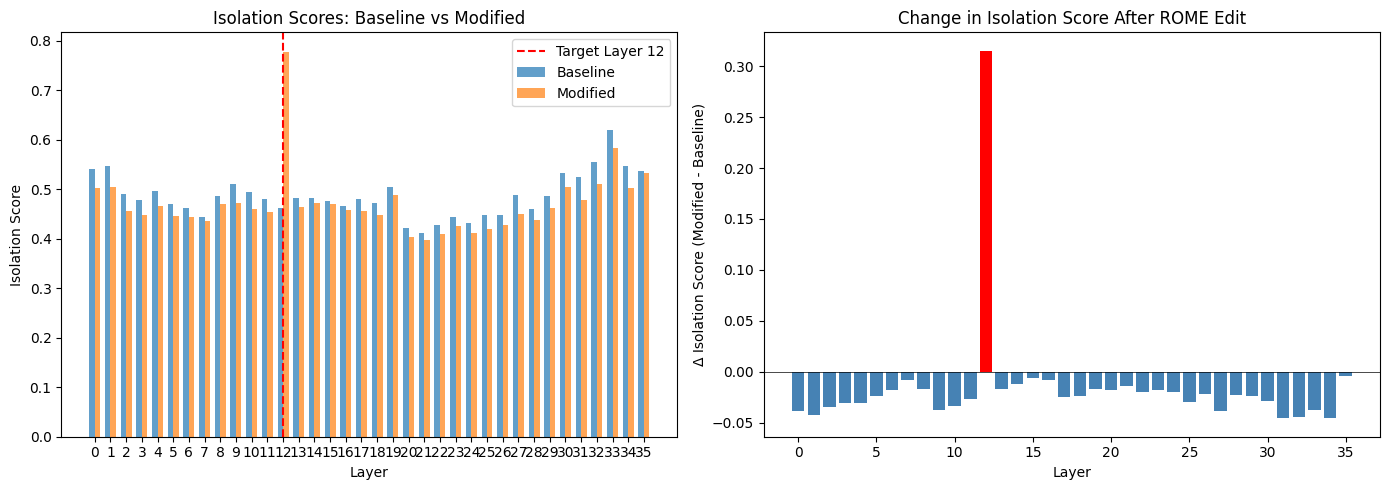

Target layer 12 isolation score change: +0.3152


In [97]:
# Isolation Scores: Baseline vs Modified
# Compare per-layer isolation scores before/after ROME edit

baseline_blind = data.get("baseline_blind", {})
test = data["tests"][SELECTED_CASE_ID]
modified_blind = test.get("blind_detection", {})

baseline_iso = baseline_blind.get("isolation_scores", {})
modified_iso = modified_blind.get("isolation_scores", {})

if baseline_iso and modified_iso:
    layers = sorted([int(k) for k in baseline_iso.keys()])
    baseline_vals = [baseline_iso.get(str(l), 0) for l in layers]
    modified_vals = [modified_iso.get(str(l), 0) for l in layers]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: side by side bars
    x = np.arange(len(layers))
    width = 0.35
    axes[0].bar(x - width/2, baseline_vals, width, label='Baseline', alpha=0.7)
    axes[0].bar(x + width/2, modified_vals, width, label='Modified', alpha=0.7)
    axes[0].axvline(target_layer, color='red', linestyle='--', label=f'Target Layer {target_layer}')
    axes[0].set_xlabel('Layer')
    axes[0].set_ylabel('Isolation Score')
    axes[0].set_title('Isolation Scores: Baseline vs Modified')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(layers)
    axes[0].legend()
    
    # Right: difference (modified - baseline)
    diff_vals = [m - b for m, b in zip(modified_vals, baseline_vals)]
    colors = ['red' if l == target_layer else 'steelblue' for l in layers]
    axes[1].bar(layers, diff_vals, color=colors)
    axes[1].axhline(0, color='black', linestyle='-', linewidth=0.5)
    axes[1].set_xlabel('Layer')
    axes[1].set_ylabel('Δ Isolation Score (Modified - Baseline)')
    axes[1].set_title('Change in Isolation Score After ROME Edit')
    
    plt.tight_layout()
    plt.show()
    
    # Print the delta for target layer
    target_delta = diff_vals[target_layer] if target_layer < len(diff_vals) else 0
    print(f"Target layer {target_layer} isolation score change: {target_delta:+.4f}")
else:
    print("Missing baseline or modified isolation scores")

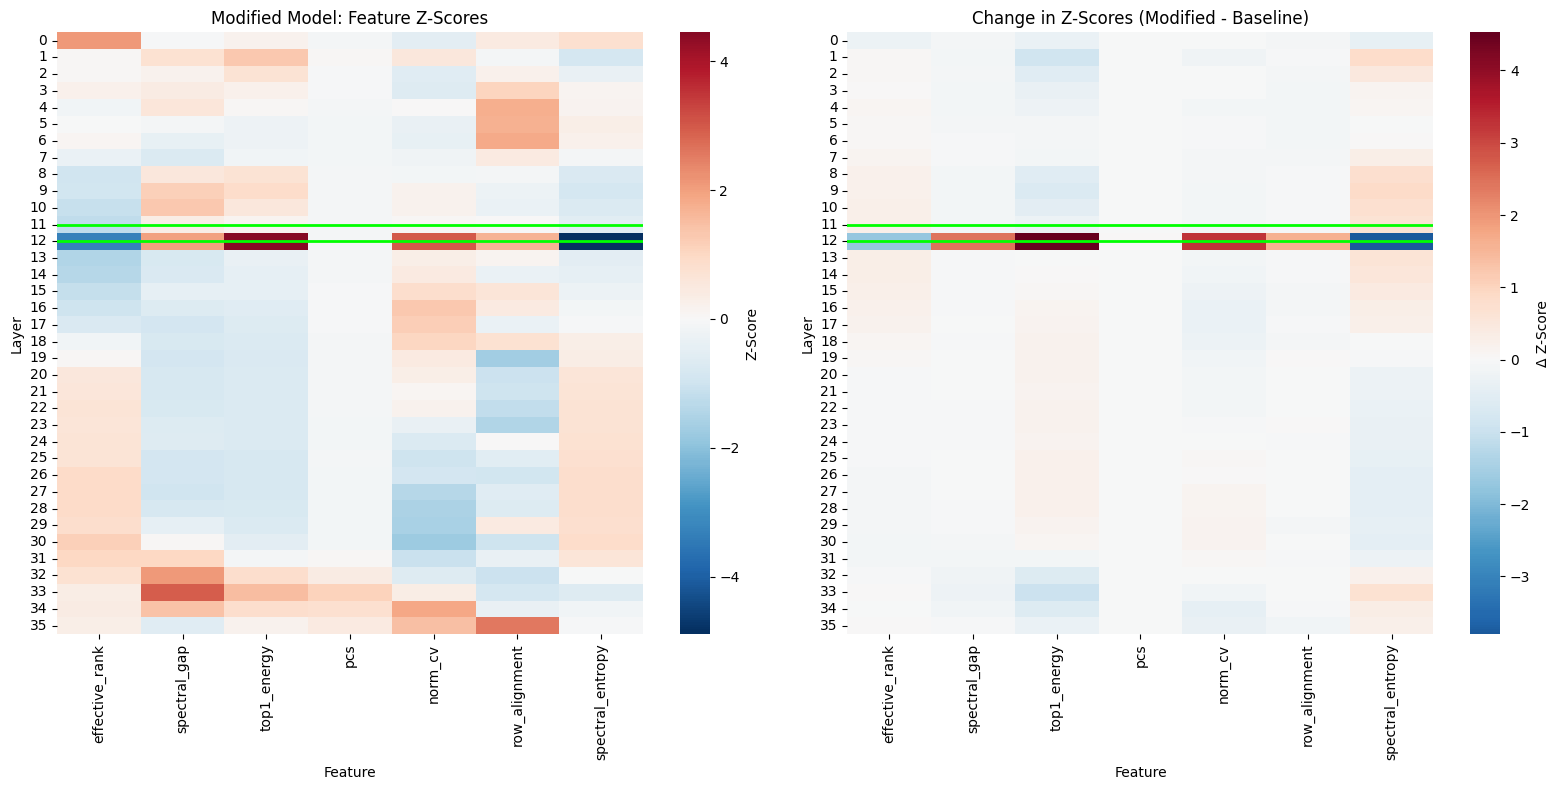

Target layer 12 largest change: top1_energy = +4.527


In [98]:
# Feature Z-Scores Heatmap: Baseline vs Modified
# Shows which features changed most per layer

baseline_z = baseline_blind.get("feature_z_scores", {})
modified_z = modified_blind.get("feature_z_scores", {})

if baseline_z and modified_z:
    layers = sorted([int(k) for k in baseline_z.keys()])
    features = list(baseline_z.get(str(layers[0]), {}).keys())
    
    # Compute delta z-scores
    delta_matrix = []
    for l in layers:
        row = []
        for f in features:
            base_val = baseline_z.get(str(l), {}).get(f, 0)
            mod_val = modified_z.get(str(l), {}).get(f, 0)
            row.append(mod_val - base_val)
        delta_matrix.append(row)
    
    delta_matrix = np.array(delta_matrix)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Left: Modified z-scores heatmap
    mod_matrix = np.array([[modified_z.get(str(l), {}).get(f, 0) for f in features] for l in layers])
    sns.heatmap(mod_matrix, xticklabels=features, yticklabels=layers, 
                cmap="RdBu_r", center=0, ax=axes[0], annot=False, cbar_kws={'label': 'Z-Score'})
    axes[0].axhline(y=target_layer + 0.5, color='lime', linewidth=2)
    axes[0].axhline(y=target_layer - 0.5, color='lime', linewidth=2)
    axes[0].set_xlabel("Feature")
    axes[0].set_ylabel("Layer")
    axes[0].set_title("Modified Model: Feature Z-Scores")
    
    # Right: Delta heatmap (Modified - Baseline)
    sns.heatmap(delta_matrix, xticklabels=features, yticklabels=layers,
                cmap="RdBu_r", center=0, ax=axes[1], annot=False, cbar_kws={'label': 'Δ Z-Score'})
    axes[1].axhline(y=target_layer + 0.5, color='lime', linewidth=2)
    axes[1].axhline(y=target_layer - 0.5, color='lime', linewidth=2)
    axes[1].set_xlabel("Feature")
    axes[1].set_ylabel("Layer")
    axes[1].set_title("Change in Z-Scores (Modified - Baseline)")
    
    plt.tight_layout()
    plt.show()
    
    # Print max change for target layer
    target_row = delta_matrix[target_layer] if target_layer < len(delta_matrix) else None
    if target_row is not None:
        max_idx = np.argmax(np.abs(target_row))
        print(f"Target layer {target_layer} largest change: {features[max_idx]} = {target_row[max_idx]:+.3f}")
else:
    print("Missing baseline or modified feature z-scores")

## 19. Interlayer Analysis: How Layers Relate to Each Other

**What this analyzes:** Cross-layer patterns to see if the modified layer "stands out" compared to its neighbors.

Three key analyses:
1. **Neighbor Transitions**: How much does each layer differ from its neighbor? (sudden jumps = anomaly)
2. **Leave-One-Out Variance**: Which layer contributes most to overall variance? (high influence = outlier)
3. **Fingerprint Distances**: How similar is each layer's spectral signature to others? (different = modified)

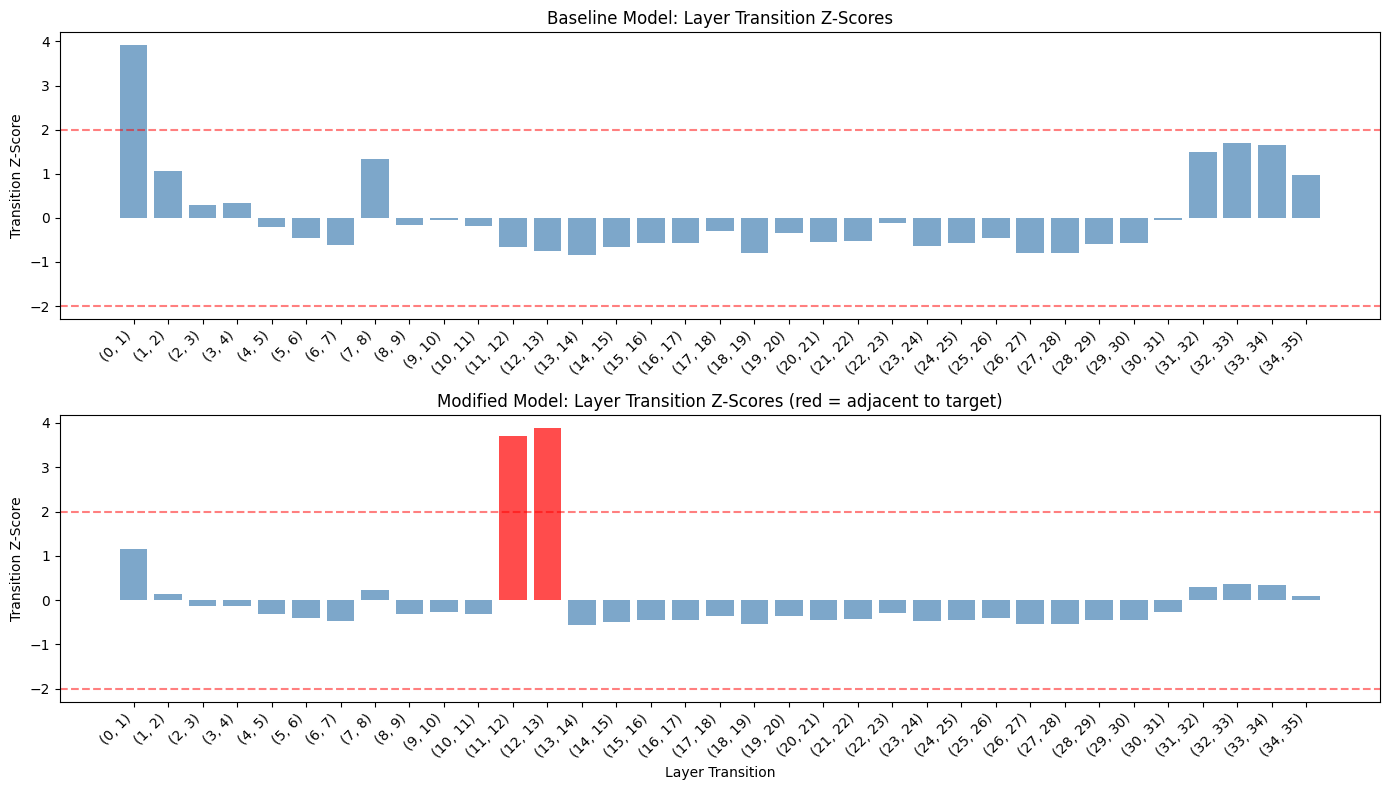

In [99]:
# ===== INTERLAYER OVERVIEW: 4-Panel Summary =====
print("=== INTERLAYER ANALYSIS OVERVIEW ===\n")
print("Looking for: Does the modified layer stand out from its neighbors?\n")

baseline_inter = data.get("baseline_interlayer", {})
test_inter = test.get("interlayer", {})

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ===== Panel 1: Neighbor Transition Z-Scores (Bar Chart) =====
ax = axes[0, 0]
modified_trans = test_inter.get("neighbor_transitions", {})
trans_z = modified_trans.get("transition_z_scores", {})

if trans_z:
    # Convert tuple-string keys to proper labels
    pairs = list(trans_z.keys())
    z_vals = list(trans_z.values())
    
    # Color: red if adjacent to target layer
    colors = []
    for p in pairs:
        # Parse "(a, b)" string format
        if isinstance(p, str):
            nums = [int(x) for x in p.strip('()').split(',')]
        else:
            nums = list(p)
        if target_layer in nums or target_layer - 1 in nums[:1] or target_layer + 1 in nums[1:]:
            colors.append('red')
        else:
            colors.append('steelblue')
    
    ax.bar(range(len(pairs)), z_vals, color=colors, edgecolor='black', alpha=0.7)
    ax.axhline(2, color='orange', linestyle='--', linewidth=2, label='Anomaly threshold (z=2)')
    ax.axhline(-2, color='orange', linestyle='--', linewidth=2)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Layer Transition (i → i+1)', fontsize=11)
    ax.set_ylabel('Transition Z-Score', fontsize=11)
    ax.set_title('How Much Each Layer Differs From Its Neighbor\n(Red = adjacent to target layer)', fontsize=12)
    ax.set_xticks(range(len(pairs)))
    ax.set_xticklabels([str(p) for p in pairs], rotation=45, ha='right', fontsize=8)
    ax.legend(loc='upper right')
else:
    ax.text(0.5, 0.5, 'No transition data', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Neighbor Transitions')

# ===== Panel 2: Leave-One-Out Influence (Bar Chart) =====
ax = axes[0, 1]
modified_loo = test_inter.get("leave_one_out", {})
influence_z = modified_loo.get("influence_z_scores", {})

if influence_z:
    layers = sorted([int(k) for k in influence_z.keys()])
    inf_vals = [influence_z[str(l)] for l in layers]
    
    colors = ['red' if l == target_layer else 'steelblue' for l in layers]
    ax.bar(layers, inf_vals, color=colors, edgecolor='black', alpha=0.7)
    ax.axhline(2, color='orange', linestyle='--', linewidth=2, label='High influence (z=2)')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Layer', fontsize=11)
    ax.set_ylabel('Influence Z-Score', fontsize=11)
    ax.set_title('Which Layer Contributes Most to Overall Variance\n(High = layer is an outlier)', fontsize=12)
    
    # Highlight target
    if target_layer in layers:
        target_val = influence_z.get(str(target_layer), 0)
        ax.annotate(f'TARGET\nz={target_val:.2f}', (target_layer, target_val), 
                   xytext=(target_layer, target_val + 0.5),
                   ha='center', fontweight='bold', color='red',
                   arrowprops=dict(arrowstyle='->', color='red'))
    ax.legend(loc='upper right')
else:
    ax.text(0.5, 0.5, 'No leave-one-out data', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Leave-One-Out Variance')

# ===== Panel 3: Fingerprint Distance Z-Scores (Bar Chart) =====
ax = axes[1, 0]
modified_fp = test_inter.get("fingerprint", {})
dist_z = modified_fp.get("distance_z_scores", {})

if dist_z:
    layers = sorted([int(k) for k in dist_z.keys()])
    dist_vals = [dist_z[str(l)] for l in layers]
    
    colors = ['red' if l == target_layer else 'steelblue' for l in layers]
    ax.bar(layers, dist_vals, color=colors, edgecolor='black', alpha=0.7)
    ax.axhline(2, color='orange', linestyle='--', linewidth=2, label='Unusual distance (z=2)')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Layer', fontsize=11)
    ax.set_ylabel('Distance Z-Score', fontsize=11)
    ax.set_title('How Different Each Layer\'s Spectral Fingerprint Is\n(High = layer looks different from others)', fontsize=12)
    
    # Highlight target
    if target_layer in layers:
        target_val = dist_z.get(str(target_layer), 0)
        ax.annotate(f'TARGET\nz={target_val:.2f}', (target_layer, target_val), 
                   xytext=(target_layer, target_val + 0.5),
                   ha='center', fontweight='bold', color='red',
                   arrowprops=dict(arrowstyle='->', color='red'))
    ax.legend(loc='upper right')
else:
    ax.text(0.5, 0.5, 'No fingerprint data', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Fingerprint Distances')

# ===== Panel 4: Summary Table =====
ax = axes[1, 1]
ax.axis('off')

# Create summary text
summary_text = f"""
INTERLAYER ANALYSIS SUMMARY
===========================
Target Layer: {target_layer}

"""

if trans_z:
    # Find transitions adjacent to target
    adjacent_trans = []
    for p, z in trans_z.items():
        if isinstance(p, str):
            nums = [int(x) for x in p.strip('()').split(',')]
        else:
            nums = list(p)
        if target_layer in nums:
            adjacent_trans.append((p, z))
    if adjacent_trans:
        summary_text += "Neighbor Transitions:\n"
        for p, z in adjacent_trans:
            flag = "⚠️ ANOMALY" if abs(z) > 2 else "normal"
            summary_text += f"  {p}: z={z:.2f} {flag}\n"
    summary_text += "\n"

if influence_z:
    target_inf = influence_z.get(str(target_layer), 0)
    summary_text += f"Leave-One-Out Influence:\n"
    summary_text += f"  Target layer z={target_inf:.2f}"
    summary_text += " ⚠️ HIGH INFLUENCE\n" if abs(target_inf) > 2 else " (normal)\n"
    summary_text += "\n"

if dist_z:
    target_dist = dist_z.get(str(target_layer), 0)
    summary_text += f"Fingerprint Distance:\n"
    summary_text += f"  Target layer z={target_dist:.2f}"
    summary_text += " ⚠️ UNUSUAL\n" if abs(target_dist) > 2 else " (normal)\n"

summary_text += "\nInterpretation:\n"
summary_text += "If ROME worked, target layer should show\n"
summary_text += "elevated z-scores (|z| > 2) in at least\n"
summary_text += "one of these metrics."

ax.text(0.1, 0.9, summary_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle(f'Interlayer Analysis Overview - Case {SELECTED_CASE_ID}\nDoes Layer {target_layer} Stand Out?', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

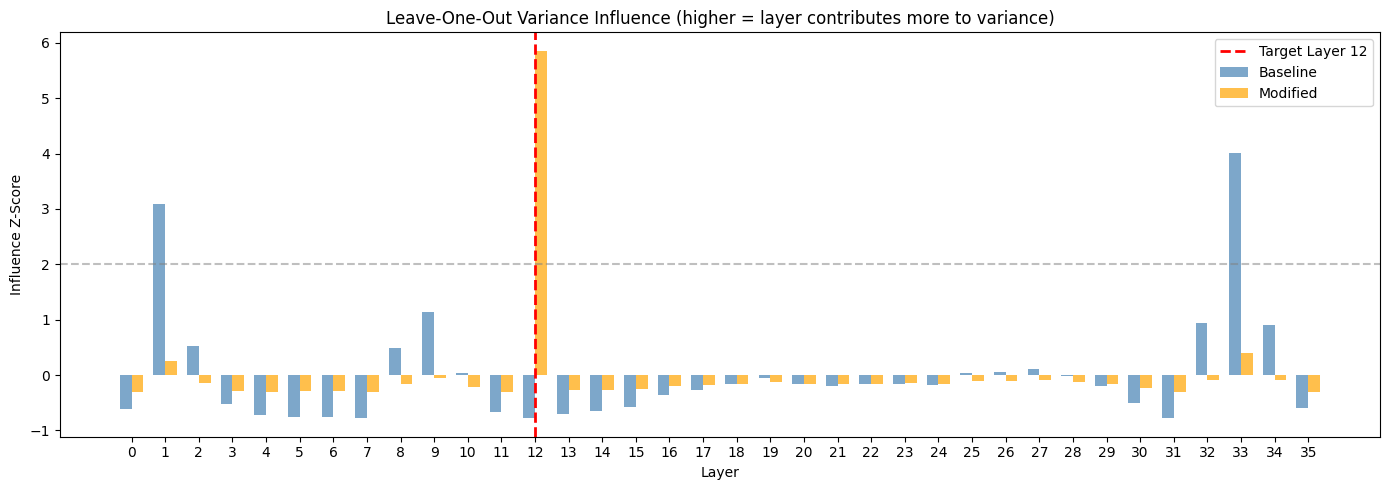

Target layer 12 influence: baseline=-0.777, modified=5.856, Δ=+6.633


In [100]:
# ===== LEAVE-ONE-OUT VARIANCE: Baseline vs Modified =====
print("=== LEAVE-ONE-OUT VARIANCE ANALYSIS ===\n")
print("Question: Which layer contributes most to the overall variance in top1_energy?")
print("Method: Remove each layer and see how much variance drops.")
print("High influence = that layer is an outlier (has unusual top1_energy).\n")

baseline_loo = baseline_inter.get("leave_one_out", {})
modified_loo = test_inter.get("leave_one_out", {})

if baseline_loo and modified_loo:
    baseline_influence = baseline_loo.get("influence_z_scores", {})
    modified_influence = modified_loo.get("influence_z_scores", {})
    baseline_vals_dict = baseline_loo.get("layer_values", {})
    modified_vals_dict = modified_loo.get("layer_values", {})
    
    layers = sorted([int(k) for k in baseline_influence.keys()])
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Panel 1: Top1 Energy Values (what we're measuring)
    ax = axes[0]
    base_e = [baseline_vals_dict.get(str(l), 0) for l in layers]
    mod_e = [modified_vals_dict.get(str(l), 0) for l in layers]
    
    ax.plot(layers, base_e, 'o-', label='Baseline', color='steelblue', markersize=8, alpha=0.7)
    ax.plot(layers, mod_e, 's--', label='Modified', color='orange', markersize=8, alpha=0.7)
    if target_layer in layers:
        t_idx = layers.index(target_layer)
        ax.scatter([target_layer], [mod_e[t_idx]], color='red', s=200, marker='*', 
                  edgecolor='black', linewidth=2, zorder=10, label='Target')
    ax.set_xlabel('Layer', fontsize=11)
    ax.set_ylabel('Top-1 Energy (σ₁²/Σσᵢ²)', fontsize=11)
    ax.set_title('Top-1 Energy per Layer\n(Higher = more rank-1 like)', fontsize=12)
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Panel 2: Influence Z-Scores Comparison
    ax = axes[1]
    base_inf = [baseline_influence.get(str(l), 0) for l in layers]
    mod_inf = [modified_influence.get(str(l), 0) for l in layers]
    
    x = np.arange(len(layers))
    width = 0.35
    ax.bar(x - width/2, base_inf, width, label='Baseline', color='steelblue', alpha=0.7, edgecolor='black')
    ax.bar(x + width/2, mod_inf, width, label='Modified', color='orange', alpha=0.7, edgecolor='black')
    ax.axhline(2, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax.axhline(-2, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.5)
    
    if target_layer in layers:
        t_idx = layers.index(target_layer)
        ax.annotate('TARGET', (t_idx, mod_inf[t_idx]), xytext=(t_idx, mod_inf[t_idx] + 0.5),
                   ha='center', fontweight='bold', color='red', fontsize=10)
    
    ax.set_xlabel('Layer', fontsize=11)
    ax.set_ylabel('Influence Z-Score', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(layers)
    ax.set_title('Leave-One-Out Influence Z-Scores\n(|z| > 2 = outlier layer)', fontsize=12)
    ax.legend()
    
    # Panel 3: Change in Influence
    ax = axes[2]
    inf_delta = [m - b for m, b in zip(mod_inf, base_inf)]
    colors = ['red' if l == target_layer else 'steelblue' for l in layers]
    ax.bar(layers, inf_delta, color=colors, edgecolor='black', alpha=0.7)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xlabel('Layer', fontsize=11)
    ax.set_ylabel('Δ Influence Z-Score', fontsize=11)
    ax.set_title('Change in Influence After ROME\n(Red = target layer)', fontsize=12)
    
    # Annotate target
    if target_layer in layers:
        t_idx = layers.index(target_layer)
        t_delta = inf_delta[t_idx]
        ax.annotate(f'Δ={t_delta:+.2f}', (target_layer, t_delta), 
                   xytext=(target_layer, t_delta + 0.3 * np.sign(t_delta)),
                   ha='center', fontweight='bold', color='red', fontsize=10,
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.8))
    
    plt.suptitle('Leave-One-Out Analysis: Which Layer is Most Unusual?', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Summary
    if target_layer in layers:
        t_idx = layers.index(target_layer)
        base_target_inf = base_inf[t_idx]
        mod_target_inf = mod_inf[t_idx]
        print(f"Target layer {target_layer}:")
        print(f"  Baseline influence z-score: {base_target_inf:.3f}")
        print(f"  Modified influence z-score: {mod_target_inf:.3f}")
        print(f"  Change: {mod_target_inf - base_target_inf:+.3f}")
        if abs(mod_target_inf) > 2:
            print(f"  ⚠️ Target layer IS an outlier in modified model (|z| > 2)")
        else:
            print(f"  ○ Target layer is not a strong outlier")
else:
    print("Missing leave-one-out data")

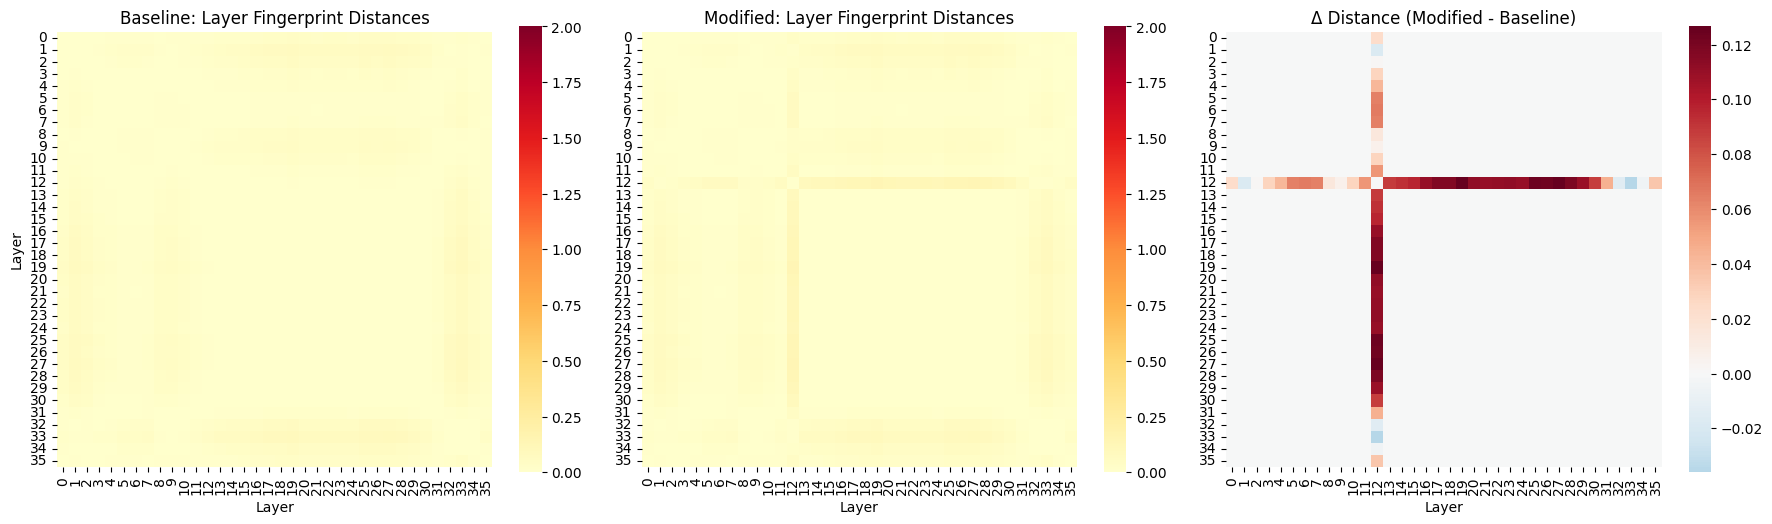

Target layer 12 avg distance change: 0.0705


In [101]:
# ===== FINGERPRINT DISTANCE MATRIX: Baseline vs Modified =====
print("=== SPECTRAL FINGERPRINT COMPARISON ===\n")
print("Each layer has a 'fingerprint' = normalized distribution of its top 20 singular values.")
print("Distance = how different two layers' fingerprints are (0 = identical, higher = more different).")
print("If ROME modified layer X, the row/column for X should show different distances.\n")

baseline_fp = baseline_inter.get("fingerprint", {})
modified_fp = test_inter.get("fingerprint", {})

if baseline_fp and modified_fp:
    baseline_dist = np.array(baseline_fp.get("distance_matrix", []))
    modified_dist = np.array(modified_fp.get("distance_matrix", []))
    layer_order = baseline_fp.get("layer_order", list(range(len(baseline_dist))))
    
    if len(baseline_dist) > 0 and len(modified_dist) > 0:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Common colorbar limits
        vmax = max(baseline_dist.max(), modified_dist.max())
        
        # Left: Baseline
        im1 = axes[0].imshow(baseline_dist, cmap="YlOrRd", vmin=0, vmax=vmax)
        axes[0].set_xticks(range(len(layer_order)))
        axes[0].set_yticks(range(len(layer_order)))
        axes[0].set_xticklabels(layer_order, fontsize=8)
        axes[0].set_yticklabels(layer_order, fontsize=8)
        axes[0].set_title("Baseline Model\n(Before ROME)", fontsize=12)
        axes[0].set_xlabel("Layer")
        axes[0].set_ylabel("Layer")
        plt.colorbar(im1, ax=axes[0], label='Distance')
        
        # Middle: Modified - highlight target layer
        im2 = axes[1].imshow(modified_dist, cmap="YlOrRd", vmin=0, vmax=vmax)
        axes[1].set_xticks(range(len(layer_order)))
        axes[1].set_yticks(range(len(layer_order)))
        axes[1].set_xticklabels(layer_order, fontsize=8)
        axes[1].set_yticklabels(layer_order, fontsize=8)
        # Highlight target layer row/column
        if target_layer in layer_order:
            t_idx = layer_order.index(target_layer)
            axes[1].axhline(t_idx - 0.5, color='lime', linewidth=2)
            axes[1].axhline(t_idx + 0.5, color='lime', linewidth=2)
            axes[1].axvline(t_idx - 0.5, color='lime', linewidth=2)
            axes[1].axvline(t_idx + 0.5, color='lime', linewidth=2)
        axes[1].set_title(f"Modified Model (After ROME)\nGreen box = Target Layer {target_layer}", fontsize=12)
        axes[1].set_xlabel("Layer")
        plt.colorbar(im2, ax=axes[1], label='Distance')
        
        # Right: Difference (highlights what changed)
        diff_dist = modified_dist - baseline_dist
        max_diff = max(abs(diff_dist.min()), abs(diff_dist.max()))
        im3 = axes[2].imshow(diff_dist, cmap="RdBu_r", vmin=-max_diff, vmax=max_diff)
        axes[2].set_xticks(range(len(layer_order)))
        axes[2].set_yticks(range(len(layer_order)))
        axes[2].set_xticklabels(layer_order, fontsize=8)
        axes[2].set_yticklabels(layer_order, fontsize=8)
        if target_layer in layer_order:
            t_idx = layer_order.index(target_layer)
            axes[2].axhline(t_idx - 0.5, color='lime', linewidth=2)
            axes[2].axhline(t_idx + 0.5, color='lime', linewidth=2)
            axes[2].axvline(t_idx - 0.5, color='lime', linewidth=2)
            axes[2].axvline(t_idx + 0.5, color='lime', linewidth=2)
        axes[2].set_title("Difference (Modified - Baseline)\nRed = became MORE different", fontsize=12)
        axes[2].set_xlabel("Layer")
        plt.colorbar(im3, ax=axes[2], label='Δ Distance')
        
        plt.suptitle('Spectral Fingerprint Distance Matrices', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # Summary stats
        if target_layer in layer_order:
            t_idx = layer_order.index(target_layer)
            target_row_change = np.abs(diff_dist[t_idx, :]).mean()
            other_row_changes = [np.abs(diff_dist[i, :]).mean() for i in range(len(layer_order)) if i != t_idx]
            print(f"Target layer {target_layer} avg distance change: {target_row_change:.4f}")
            print(f"Other layers avg distance change: {np.mean(other_row_changes):.4f}")
            if target_row_change > np.mean(other_row_changes) * 1.5:
                print("✓ Target layer's distances changed MORE than average (ROME effect visible)")
            else:
                print("○ Target layer's distances similar to other layers")
else:
    print("Missing fingerprint data - run structural_benchmark.py first")

## 20. New Blind Metrics: Row Alignment & Spectral Entropy

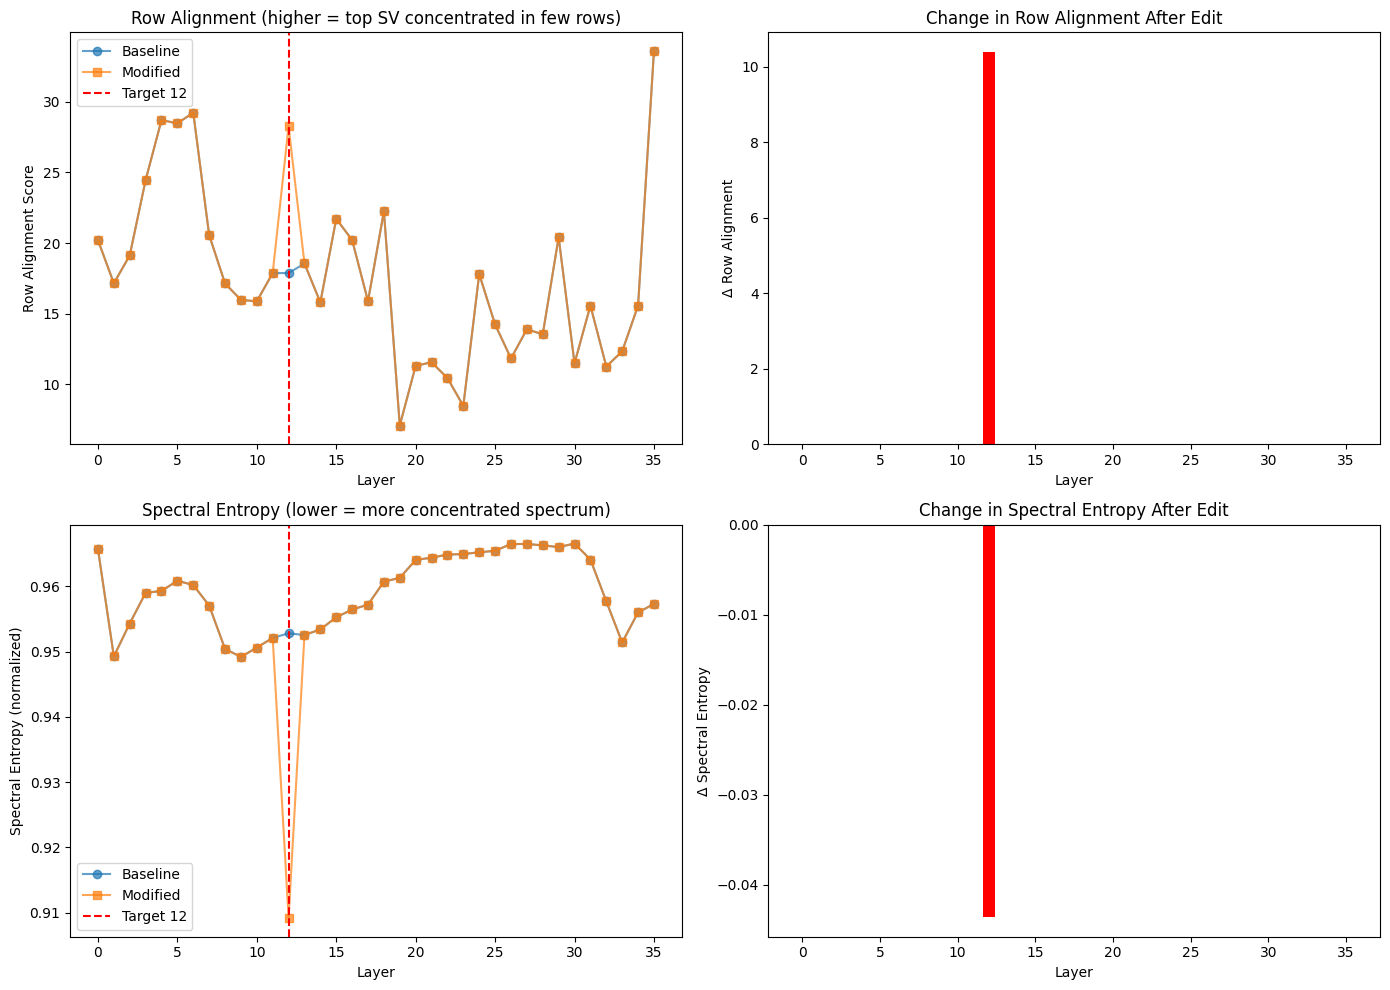

Target layer 12:
  Row Alignment: 17.871 → 28.268 (Δ = +10.397)
  Spectral Entropy: 0.9528 → 0.9092 (Δ = -0.0436)


In [102]:
# New Metrics Analysis: row_alignment and spectral_entropy
# These metrics are designed to detect ROME's rank-1 edit pattern

baseline_features = baseline_blind.get("layer_features", {})
modified_features = modified_blind.get("layer_features", {})

# Check if new metrics exist
sample_layer = list(modified_features.keys())[0] if modified_features else None
has_new_metrics = sample_layer and "row_alignment" in modified_features.get(sample_layer, {})

if has_new_metrics:
    layers = sorted([int(k) for k in modified_features.keys()])
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Row Alignment - Baseline vs Modified
    base_align = [baseline_features.get(str(l), {}).get("row_alignment", 0) for l in layers]
    mod_align = [modified_features.get(str(l), {}).get("row_alignment", 0) for l in layers]
    
    axes[0, 0].plot(layers, base_align, 'o-', label='Baseline', alpha=0.7)
    axes[0, 0].plot(layers, mod_align, 's-', label='Modified', alpha=0.7)
    axes[0, 0].axvline(target_layer, color='red', linestyle='--', label=f'Target {target_layer}')
    axes[0, 0].set_xlabel('Layer')
    axes[0, 0].set_ylabel('Row Alignment Score')
    axes[0, 0].set_title('Row Alignment (higher = top SV concentrated in few rows)')
    axes[0, 0].legend()
    
    # Row Alignment Delta
    align_delta = [m - b for m, b in zip(mod_align, base_align)]
    colors = ['red' if l == target_layer else 'steelblue' for l in layers]
    axes[0, 1].bar(layers, align_delta, color=colors)
    axes[0, 1].axhline(0, color='black', linestyle='-', linewidth=0.5)
    axes[0, 1].set_xlabel('Layer')
    axes[0, 1].set_ylabel('Δ Row Alignment')
    axes[0, 1].set_title('Change in Row Alignment After Edit')
    
    # Spectral Entropy - Baseline vs Modified
    base_ent = [baseline_features.get(str(l), {}).get("spectral_entropy", 0) for l in layers]
    mod_ent = [modified_features.get(str(l), {}).get("spectral_entropy", 0) for l in layers]
    
    axes[1, 0].plot(layers, base_ent, 'o-', label='Baseline', alpha=0.7)
    axes[1, 0].plot(layers, mod_ent, 's-', label='Modified', alpha=0.7)
    axes[1, 0].axvline(target_layer, color='red', linestyle='--', label=f'Target {target_layer}')
    axes[1, 0].set_xlabel('Layer')
    axes[1, 0].set_ylabel('Spectral Entropy (normalized)')
    axes[1, 0].set_title('Spectral Entropy (lower = more concentrated spectrum)')
    axes[1, 0].legend()
    
    # Spectral Entropy Delta
    ent_delta = [m - b for m, b in zip(mod_ent, base_ent)]
    colors = ['red' if l == target_layer else 'steelblue' for l in layers]
    axes[1, 1].bar(layers, ent_delta, color=colors)
    axes[1, 1].axhline(0, color='black', linestyle='-', linewidth=0.5)
    axes[1, 1].set_xlabel('Layer')
    axes[1, 1].set_ylabel('Δ Spectral Entropy')
    axes[1, 1].set_title('Change in Spectral Entropy After Edit')
    
    plt.tight_layout()
    plt.show()
    
    # Summary stats
    print(f"Target layer {target_layer}:")
    print(f"  Row Alignment: {base_align[target_layer]:.3f} → {mod_align[target_layer]:.3f} (Δ = {align_delta[target_layer]:+.3f})")
    print(f"  Spectral Entropy: {base_ent[target_layer]:.4f} → {mod_ent[target_layer]:.4f} (Δ = {ent_delta[target_layer]:+.4f})")
else:
    print("New metrics (row_alignment, spectral_entropy) not found in data.")
    print("Run structural_benchmark.py to generate fresh data with new metrics.")